# Archivist Reliability Analysis

**A Comprehensive Study of Data Durability in Erasure-Coded Decentralized Storage**

---

## Executive Summary

This document presents a rigorous reliability analysis of the
[Archivist](https://docs.archivist.storage/learn/whitepaper)
decentralized storage network (DSN). We model, simulate, and quantify the
annualized **data-loss intensity** ($\lambda_{\text{loss/year}}$) and the
corresponding horizon probability $P_{\text{loss}}(T)$ under realistic
failure, detection, repair, and reserved-Byzantine-budget assumptions.

**Key findings:**

| Result | Detail |
|--------|--------|
| **The shared durability target is achievable in the baseline model** | Within the scanned design band, moderate redundancy is sufficient under the independent-failure and effective-detection assumptions stated below |
| **Proof cadence slack is configuration-dependent** | Within the shared proof-cadence scan, stronger codes retain materially more margin than near-threshold ones |
| **Lazy repair can be viable** | Higher repair thresholds can reduce operational cost when the code still retains enough redundancy headroom |
| **Byzantine reserve erodes margins predictably** | Higher reserved Byzantine fractions ($\beta$) reduce effective parity and push the minimum viable code size upward in a quantifiable way |
| **Backends cross-check the same trends** | CTMC gives the reference result, event-driven simulation matches the same continuous-time model, and discrete-time simulation provides a timestep approximation |

### How to read this document

- **Section 1**: System model, assumptions, and key parameters
- **Section 2**: CTMC framework and interpretation of loss intensity
- **Section 3**: Implementation of all three computational backends
- **Sections 4-7**: Parameter studies, cross-validation, heatmaps, reference tables
- **Section 8**: Findings, recommendations, limitations, and extensions


## 0. Analysis Contract

### Core Question

> For a chosen erasure code $(k, m)$, Byzantine reserve fraction $\beta$,
> proof interval $\tau$ (MTTT), and repair parameters, what is the
> **annualized probability of irrecoverable data loss**?

Equivalently: given a durability target $\theta$, what is the maximum
proof cadence, repair time, or Byzantine fraction the system can tolerate?

### Canonical Definitions

| Symbol | Meaning |
|--------|---------|
| $k$ | Number of data slots (minimum for reconstruction) |
| $n = k + m$ | Total slots (data + parity) |
| $m = n - k$ | Parity (redundancy) slots |
| $\beta$ | Fraction of slots reserved against Byzantine participation |
| $b = \lceil \beta n \rceil$ | Number of reserved slots |
| $n_{\text{eff}} = n - b$ | Effective slot count after reserve |
| $m_{\text{eff}} = m - b$ | Effective parity after reserve |
| $\tau$ (MTTT) | Mean time between storage proofs per slot (hours) |
| MTTR | Mean time to repair once detected (hours) |
| MTTF | Mean time to failure per slot (hours), derived from AFR |
| $\ell_0$ (l0) | Repair threshold - min detected failures before repair triggers |
| $\lambda_{\text{loss}}$ | Loss intensity (failures per unit time) |
| $P_{\text{loss}}(T)$ | Probability of at least one loss in horizon $T$ |

$$P_{\text{loss}}(T) = 1 - e^{-\lambda_{\text{loss}} \cdot T} \;\approx\; \lambda_{\text{loss}} \cdot T \quad\text{(rare-event regime)}$$

### Reporting Rules

- Report both $\lambda_{\text{loss/year}}$ (intensity) and $P_{\text{loss}}(1\,\text{yr})$ where useful.
- Horizon $T = 8760\,\text{h}$ (one calendar year).
- Target: $\lambda_{\text{loss/year}} < 10^{-9}$ ("nine nines" annual durability).

### Decision Rule

$$\tau_{\max}(k, m, \beta;\, \theta, T) \;=\; \max\bigl\{\tau : P_{\text{loss}}(T \mid k, m, \beta, \tau) \le \theta\bigr\}$$

The studies below answer this for representative operating points generated
from the shared sensitivity configuration axes.  All shared parameters
(sensitivity config grid, beta levels, and sweep ranges) are defined once in
the configuration cell (Section 3.0) and displayed in the cell that follows it.


## 1. System Model

### 1.1 Erasure-Coded Storage

A dataset $\mathcal{D}$ is split into $k$ **data slots** and encoded via
Reed-Solomon erasure coding into $n = k + m$ total slots, where $m$ is the
number of **parity slots**. The **expansion factor** is $e = n/k$.

Any $k$-of-$n$ slots suffice to reconstruct $\mathcal{D}$.

To represent network-wide Byzantine tolerance as a first-class model parameter,
we reserve:

$$
b = \lceil \beta n \rceil
$$

slots against colluding or otherwise unusable providers. The stochastic model
then runs on:

$$
n_{eff} = n - b,
\qquad
m_{eff} = n_{eff} - k = (n-k) - b
$$

so data loss in the stochastic model occurs when more than $m_{eff}$ of those
remaining slots are lost:

$$
\text{Data loss} \iff |\{i : \text{effective slot}_i \text{ is lost}\}| > m_{eff}
$$

### 1.2 Slot Lifecycle

Each of the $n$ slots is hosted by an independent storage provider (SP) and
follows a stochastic lifecycle:

```
┌─────────┐  failure (λ=1/MTTF)  ┌────────┐  detection (1/MTTT)  ┌──────────┐
│  ALIVE  │ ───────────────────->  │  LOST  │ ──────────────────->  │ OBSERVED │
└─────────┘                       └────────┘                      └──────────┘
     ↑                                                                  │
     │                        repair (1/MTTR)                           │
     └──────────────────────────────────────────────────────────────────┘
                              (when observed >= ℓ₀)
```

### 1.3 Key Parameters

| Symbol | Name | Description |
|--------|------|-------------|
| $k$ | Data slots | Minimum slots for reconstruction |
| $n$ | Total slots | $k + m$ where $m$ is parity |
| $e$ | Expansion factor | $n / k$ |
| $\beta$ | Byzantine reserve fraction | Fraction of slots reserved against colluding or unusable providers |
| $\ell_0$ | Repair threshold | Observed losses needed to trigger repair |
| MTTF | Mean time to failure | Average time before a slot fails |
| MTTT | Mean time to test | Average proof or detection interval per slot |
| MTTR | Mean time to repair | Average time to reconstruct and re-host |
| $\lambda_{\text{loss/year}}$ | Loss intensity | Annualized event intensity of irrecoverable data loss |

The active study values are defined once in the shared configuration block
immediately after Section 3.1 and are not duplicated here.

**Failure calibration via AFR:** operational disk datasets are often reported in
terms of **annualized failure rate** (AFR) rather than MTTF. The CTMC uses
exponential failure clocks, so the natural mapping is:

$$
\lambda_{\mathrm{fail/year}} = -\ln(1-\mathrm{AFR}),
\qquad
\mathrm{MTTF}_{\mathrm{hours}} = \frac{8760}{\lambda_{\mathrm{fail/year}}}
$$

For small AFR, this is well approximated by
$\mathrm{MTTF}_{\mathrm{hours}} \approx 8760 / \mathrm{AFR}$. In practice,
deployment-specific calibration should start from observed AFR values (for example,
Backblaze-style drive datasets or protocol-specific operating data), then convert
into the continuous-time failure input used by the model.

The baseline AFR used by the notebook is defined in the shared configuration
block after Section 3.1. In the current default configuration, it is sourced
from Backblaze's reported **2025 annual fleet AFR**, published in February 2026
in [*Backblaze Drive Stats for 2025*](https://www.backblaze.com/blog/backblaze-drive-stats-for-2025/).

### 1.4 Failure Detection via Storage Proofs

The baseline reliability model is intentionally protocol-agnostic:

- each failed-undetected slot is "noticed" by proofs with rate $1/\mathrm{MTTT}$,
- once a proof event touches that slot, detection is assumed perfect.

Equivalently, the baseline sets a detectability factor $q_{\mathrm{det}} = 1$
at proof time. This is a strong assumption that can represent either:

- full-slot verification, or
- an in-slot proof protocol configured to make miss probability negligible.

When linking a concrete audit design into the reliability model, the code also
supports $q_{\mathrm{det}} < 1$. Unless stated otherwise, the parameter sweeps
below use the idealized baseline $q_{\mathrm{det}} = 1$.

### 1.5 Audit Model Variants and Detectability

This notebook keeps only the **interface** between audit design and the
reliability model.

- Detailed audit regimes (HAIL-like checks, in-slot sampling, touch budgets,
  and $\alpha$-amplification tradeoffs) are not part of this analysis and will be 
  available separately.

For reliability sweeps, convert an audit policy into:

$$
q_{\mathrm{det}} \in [0,1],
\qquad
\mathrm{MTTT}_{\mathrm{eff}} = \frac{n\,\tau_{\mathrm{epoch}}}{s_{\mathrm{slots}}}
$$

and use effective detection hazard:

$$
\lambda_{\mathrm{detect}} = \frac{q_{\mathrm{det}}}{\mathrm{MTTT}_{\mathrm{eff}}}
$$

where the idealized baseline model corresponds to $q_{\mathrm{det}} = 1$ and
$\mathrm{MTTT}_{\mathrm{eff}} = \mathrm{MTTT}$. If a Byzantine reserve is active,
$\mathrm{MTTT}_{\mathrm{eff}}$ should be interpreted on the effective stochastic slot
set of size $n_{eff}$. Practical bridge examples may instead use a near-perfect value of
$q_{\mathrm{det}}$ slightly below one. In code, the analytical and
simulation backends accept this directly as `mttt=MTTT_eff` and `q_det=q_det`.

The slot universe used in $\mathrm{MTTT}_{\mathrm{eff}}$ must match the slot
universe in the CTMC. Any finer-grained in-slot sampling should be folded into
$q_{\mathrm{det}}$, not into the CTMC's $n$.

### 1.6 Plain-English Reading of the Model

At a high level, the reliability model has three competing clocks:

- failures add lost slots at a rate set by MTTF,
- proofs detect already-lost slots at a rate set by MTTT and $q_{det}$,
- repair resets the object once observed losses reach $\ell_0$, at a rate set by MTTR.

Data loss happens when failures accumulate faster than detection and repair can catch up.
That makes the main design levers easy to interpret:

- more redundancy increases how many failures the object can survive,
- faster proofs shorten time-to-detection after a slot is lost,
- faster repair shortens the vulnerable window after enough losses have been observed.


## 2. Mathematical Framework: CTMC Model

### 2.1 State Space

After reserving $b = \lceil \beta n \rceil$ slots against colluding or otherwise
unusable providers, the stochastic durability model runs on an effective slot set
of size:

$$
n_{eff} = n - b
$$

with remaining stochastic parity budget:

$$
m_{eff} = n_{eff} - k = (n-k) - b
$$

We model that remaining system as a **Continuous-Time Markov Chain (CTMC)** with a
two-dimensional state space:

$$
S_{\ell, f} \quad \text{where} \quad \ell \in [0, m_{eff}{+}1], \; f \in [0, \ell]
$$

- $\ell$ = number of **actually lost** effective slots
- $f$ = number of **observed** (detected) losses, $f \leq \ell$

The total number of states is:

$$
|S| = \sum_{\ell=0}^{m_{eff}+1} (\ell + 1) = \frac{(m_{eff}+2)(m_{eff}+3)}{2}
$$

The state $S_{0,0}$ is the healthy start state. States $S_{m_{eff}+1, f}$ for any
$f$ represent **data loss** (more than $m_{eff}$ effective slots lost simultaneously).

### 2.2 Transition Rates

From state $S_{\ell, f}$, three types of transitions are possible:

**1. Slot failure** (one of the remaining healthy effective slots fails):
$$
S_{\ell, f} \xrightarrow{(n_{eff} - \ell) / \text{MTTF}} S_{\ell+1, f}
$$

**2. Loss detection** (a proof reveals an undetected loss):
$$
S_{\ell, f} \xrightarrow{(\ell - f) q_{\mathrm{det}} / \text{MTTT}} S_{\ell, f+1}
$$

**3. Repair** (triggered when observed losses reach threshold $\ell_0$):
$$
S_{\ell, f} \xrightarrow{1 / \text{MTTR}} S_{0, 0} \quad \text{if } f \geq \ell_0
$$

Repair restores the object from any surviving $k$-of-$n_{eff}$ effective slots.

### 2.3 Absorbing States and Steady-State Solution

The failure states $S_{m_{eff}+1, f}$ are **absorbing** in the true process. To
compute steady-state probabilities, we redirect transitions from failure
states back to $S_{0,0}$ with rate 1 (representing system restart after
data loss). This transforms the absorbing chain into an ergodic one.

In the rare-event regime that matters for the final durability recommendations,
the chain spends negligible time in these redirected failure states. Under that
condition, the exact choice of restart rate is not material to the reported
loss intensity; it is a bookkeeping device that lets the stationary flow expose
$\lambda_{\mathrm{loss}}$.

The **embedded discrete-time Markov chain** has transition probabilities:

$$
p_{ij} = \frac{q_{ij}}{\sum_j q_{ij}}
$$

where $q_{ij}$ are the CTMC transition rates. In code, we enumerate only the
valid triangular states $f \leq \ell$ before solving the embedded chain.
The stationary distribution
$\boldsymbol{\pi}^{\text{EMC}}$ of the embedded chain is converted to the
CTMC stationary distribution:

$$
\pi_i^{\text{CTMC}} = \frac{\pi_i^{\text{EMC}} / r_i}{\sum_j \pi_j^{\text{EMC}} / r_j}
$$

where $r_i = \sum_j q_{ij}$ is the total exit rate from state $i$.

### 2.4 Data Loss Intensity and Probability

The CTMC returns an annualized **data-loss intensity**:

$$
\lambda_{\text{loss/year}} = \left(\sum_{f=0}^{m_{eff}+1} \pi^{\text{CTMC}}_{m_{eff}+1, f}\right) \times 8760
$$

where $8760 = 24 \times 365$ converts from per-hour to per-year.

Convert intensity to horizon probability via:

$$
P_{\text{loss}}(T) = 1 - e^{-\lambda_{\text{loss/hour}} T}
$$

and for one year:

$$
P_{\text{loss}}(1\text{y}) = 1 - e^{-\lambda_{\text{loss/year}}}
$$

For rare events, $P_{\text{loss}}(1\text{y}) \approx \lambda_{\text{loss/year}}$.


## 3. Implementation

### Setup & Dependencies

This notebook is meant to be portable: it can run outside the internal repo,
on other machines, and in hosted notebook environments such as Google Colab.

The next cell checks the scientific Python stack used by this notebook.
If anything is missing or inconsistent, it refreshes a coherent package bundle
from PyPI and stops with a clear rerun message. This avoids partial upgrades
that can leave binary packages such as NumPy and pandas ABI-incompatible in
shared notebook environments.


In [35]:
import importlib.util
import subprocess
import sys

AUTO_INSTALL = True

REQUIRED = {
    "numpy": "numpy",
    "pandas": "pandas",
    "matplotlib": "matplotlib",
    "seaborn": "seaborn",
    "pydtmc": "pydtmc",
}

INSTALL_PACKAGES = [
    "numpy",
    "pandas",
    "matplotlib",
    "seaborn",
    "pydtmc",
]


def refresh_notebook_stack(reason):
    if not AUTO_INSTALL:
        raise RuntimeError(
            f"Notebook dependencies need refresh ({reason}). Install them with `python -m pip install {' '.join(INSTALL_PACKAGES)}` "
            "or set AUTO_INSTALL=True in this cell."
        )

    subprocess.check_call(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "--quiet",
            "--upgrade",
            "--force-reinstall",
            *INSTALL_PACKAGES,
        ]
    )

    raise SystemExit(
        "Refreshed notebook dependencies from PyPI. Restart the runtime or rerun the notebook from the top before continuing. "
        "This is especially important in Google Colab after binary package updates."
    )


missing = [
    pkg for mod, pkg in REQUIRED.items() if importlib.util.find_spec(mod) is None
]
if missing:
    refresh_notebook_stack(f"missing packages: {missing}")

try:
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    import matplotlib.ticker as ticker
    import seaborn as sns
except Exception as exc:
    refresh_notebook_stack(f"import error: {type(exc).__name__}: {exc}")

from itertools import product
import heapq, math, time, warnings

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", font_scale=1.2)
plt.rcParams["figure.dpi"] = 120
plt.rcParams["figure.figsize"] = (12, 6)

print("Environment ready.")


Environment ready.


In [36]:
def mttf_hours_from_afr(afr):
    if afr <= 0 or afr >= 1:
        raise ValueError("afr must be in (0,1)")
    return 8760 / (-np.log1p(-afr))


def pct_str(value, decimals=11):
    if value > 0 and (100 * value) < 10 ** (-decimals):
        return f"<{10 ** (-decimals):.{decimals}f}%"
    text = f"{100 * value:.{decimals}f}".rstrip("0").rstrip(".")
    if text in {"", "-0"}:
        text = "0"
    return f"{text}%"


def sci_str(value, decimals=3):
    return f"{value:.{decimals}e}"


def one_year_loss_probability(lambda_loss_year):
    return -np.expm1(-lambda_loss_year)


def lambda_year_pct_str(lambda_loss_year, decimals=11):
    return pct_str(one_year_loss_probability(lambda_loss_year), decimals=decimals)


def rate_pct_per_hour_str(rate_per_hour, decimals=11):
    return f"{pct_str(rate_per_hour, decimals=decimals)}/h"


def hours_label(hours):
    hours = float(hours)
    if hours.is_integer():
        return f"{int(hours)}h"
    return f"{hours:g}h"


def hours_tick_label(hours):
    hours = float(hours)
    if hours >= 24 and hours.is_integer() and int(hours) % 24 == 0:
        return f"{int(hours // 24)}d"
    return hours_label(hours)


def hours_day_display(hours):
    hours = float(hours)
    days = hours / 24
    if days.is_integer():
        return f"{int(hours)} h ({int(days)} d)"
    return f"{hours:g} h ({days:.2f} d)"


def code_config_label(k, n, l0=None, mttt=None, mttr=None):
    parts = [f"k={k}", f"n={n}", f"m={n - k}"]
    if l0 is not None:
        parts.append(f"l0={l0}")
    if mttt is not None:
        parts.append(f"MTTT={hours_label(mttt)}")
    if mttr is not None:
        parts.append(f"MTTR={hours_label(mttr)}")
    return ", ".join(parts)


def lambda_probe_column(param_name, hours):
    return f"lambda_at_{param_name}_{hours_label(hours)}"


def probe_display_column(param_name, hours):
    return f"lambda@{param_name}={hours_label(hours)}"


def join_hours(values):
    return ", ".join(hours_label(value) for value in values)


def join_pct(values):
    return ", ".join(pct_str(value) for value in values)


def reserve_slots_from_beta(n_slots, beta):
    if beta < 0 or beta > 1:
        raise ValueError("beta must be in [0,1]")
    return 0 if beta == 0 else math.ceil(beta * n_slots)


def effective_code_with_byzantine_budget(k, n_slots, beta):
    if not (1 <= k <= n_slots):
        raise ValueError("require n_slots >= k >= 1")
    parity = n_slots - k
    reserve = reserve_slots_from_beta(n_slots, beta)
    return {
        "k": k,
        "n": n_slots,
        "parity_slots": parity,
        "beta": beta,
        "reserve_slots": reserve,
        "n_eff": n_slots - reserve,
        "remaining_parity": parity - reserve,
        "structural_beta_limit": parity / n_slots,
        # Structural feasibility only. Callers that require a recoverable
        # operating point should also check remaining_parity >= l0.
        "feasible": reserve <= parity,
    }


def beta_subplots(beta_values, height=5, width_per_beta=5.25, sharey=True):
    n_beta = len(beta_values)
    if n_beta < 1:
        raise ValueError("beta_values must contain at least one value")
    fig, axes = plt.subplots(
        1,
        n_beta,
        figsize=(width_per_beta * n_beta, height),
        sharey=sharey,
    )
    return fig, np.atleast_1d(axes).ravel()


def add_loss_target_line(ax, target):
    ax.axhline(y=target, color="red", linestyle="--", alpha=0.7)


### 3.0 Configuration

All shared parameters — sensitivity grid axes, sweep ranges, beta levels,
and scalar baselines — are defined in the cell below.  Adjust values there
and re-run the notebook; every study, heatmap, and reference table derives
from this single configuration cell.

In [37]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CONFIGURATION CELL — single source of truth for all studies   ║
# ║                                                                ║
# ║  HOW TO USE:                                                   ║
# ║  • Tweak the values below and re-run the notebook.             ║
# ║  • Studies 1-4, audit bridge, heatmap, and reference tables    ║
# ║    all derive their parameters from this cell.                 ║
# ║  • STANDARD_CONFIG_INDEX selects which grid point the audit    ║
# ║    bridge and heatmap use.  Set it to any valid index into     ║
# ║    SENSITIVITY_CONFIGS (0 .. len-1), or set it to None to      ║
# ║    run those sections for ALL configs in the grid.             ║
# ╚══════════════════════════════════════════════════════════════════╝

#  Physical parameters
BASE_AFR = 0.0136  # Annual disk failure rate
BASE_MTTF_HOURS = mttf_hours_from_afr(BASE_AFR)
TARGET_LAMBDA_LOSS_YEAR = 1e-9  # Nine-nines durability target

#  Byzantine fault budget
# Fraction of slots assumed adversarial.  0 = honest-only analysis.
BETA_VALUES = [0.0, 0.10, 0.20]

#  Operational baselines
BASELINE_MTTR = 24  # Hours to replace a failed disk
BASELINE_MTTT = 24  # Hours between proof/audit checks
MTTT_SWEEP = [24, 72, 168]  # proof-frequency sweep points
MTTR_SWEEP = [24, 48, 72]  # repair-time sweep points
MTTT_STUDY_POINTS = list(MTTT_SWEEP)
MTTR_STUDY_POINTS = list(MTTR_SWEEP)

#  Code-dimension scan bounds
K_MIN = 2  # Smallest k to scan
K_MAX = 30  # Largest k to scan
N_CEIL = 50  # Maximum n allowed in any config

#  Sensitivity grid axes
# These three lists define the Cartesian grid of (k, expansion, l0)
# operating points used by Studies 2 and 3.  Studies 1, 4, and the
# reference table also use EXPANSION_FACTORS and R0_VALUES (derived
# below) so that all studies stay aligned.
SENSITIVITY_K_VALUES = [3, 5, 10]  # Data-fragment counts to probe
SENSITIVITY_EXPANSION_FACTORS = [1.5, 2.0]  # Target expansion ratios (n >= ceil(k*e))
SENSITIVITY_L0_VALUES = [1, 3]  # Repair thresholds (min lost before repair)

#  Derived from sensitivity axes (prevents drift)
EXPANSION_FACTORS = SENSITIVITY_EXPANSION_FACTORS
R0_VALUES = SENSITIVITY_L0_VALUES
STUDY3_FIXED_MTTT_HOURS = BASELINE_MTTT  # Study 3 holds MTTT fixed at baseline

#  Generated config grid
# n is computed with math.ceil so that the actual expansion n/k >= e.
# Both the intended (e) and realized (e_actual) expansion are stored;
# use e for labels/grouping, e_actual for any calculation that needs
# the true code rate.
SENSITIVITY_CONFIGS = []
for _k in SENSITIVITY_K_VALUES:
    for _ef in SENSITIVITY_EXPANSION_FACTORS:
        for _l0 in SENSITIVITY_L0_VALUES:
            _n = math.ceil(_k * _ef)
            SENSITIVITY_CONFIGS.append(
                {
                    "k": _k,
                    "n": _n,
                    "e": _ef,
                    "e_actual": _n / _k,
                    "l0": _l0,
                }
            )

#  Select operating point(s) for audit bridge & heatmap
# Set to an integer index (0 .. len-1) to pick one config, or None
# to run the audit bridge and heatmap for every config in the grid.
STANDARD_CONFIG_INDEX = 11  # <- adjust this

if STANDARD_CONFIG_INDEX is not None:
    assert 0 <= STANDARD_CONFIG_INDEX < len(SENSITIVITY_CONFIGS), (
        f"STANDARD_CONFIG_INDEX={STANDARD_CONFIG_INDEX} out of range "
        f"[0, {len(SENSITIVITY_CONFIGS)})"
    )
    STANDARD_CONFIGS = [SENSITIVITY_CONFIGS[STANDARD_CONFIG_INDEX]]
else:
    STANDARD_CONFIGS = list(SENSITIVITY_CONFIGS)

#  Validation
_config_keys = [(c["k"], c["n"], c["l0"]) for c in SENSITIVITY_CONFIGS]
assert len(_config_keys) == len(set(_config_keys)), "Duplicate (k, n, l0) configs"
assert all(c["k"] < c["n"] <= N_CEIL for c in SENSITIVITY_CONFIGS), (
    "Invalid config dimensions"
)

assert len(SENSITIVITY_CONFIGS) > 0, "Empty config set"
assert all(c["n"] / c["k"] >= c["e"] - 1e-9 for c in SENSITIVITY_CONFIGS), (
    "Realized expansion n/k < intended expansion e"
)


In [38]:
shared_params_rows = [
    {"Parameter": "Annual failure rate (AFR)", "Value": pct_str(BASE_AFR)},
    {"Parameter": "Baseline MTTF", "Value": f"{BASE_MTTF_HOURS:.0f} h"},
    {
        "Parameter": "Durability target",
        "Value": f"{sci_str(TARGET_LAMBDA_LOSS_YEAR)} / year",
    },
    {"Parameter": "Beta values", "Value": join_pct(BETA_VALUES)},
    {"Parameter": "Baseline MTTT", "Value": hours_label(BASELINE_MTTT)},
    {"Parameter": "Study 3 fixed MTTT", "Value": hours_label(STUDY3_FIXED_MTTT_HOURS)},
    {"Parameter": "Baseline MTTR", "Value": hours_label(BASELINE_MTTR)},
    {"Parameter": "MTTT sweep / study points", "Value": join_hours(MTTT_SWEEP)},
    {"Parameter": "MTTR sweep / study points", "Value": join_hours(MTTR_SWEEP)},
    {
        "Parameter": "Sensitivity k values",
        "Value": ", ".join(str(v) for v in SENSITIVITY_K_VALUES),
    },
    {
        "Parameter": "Sensitivity expansion factors",
        "Value": ", ".join(f"{v:.1f}" for v in SENSITIVITY_EXPANSION_FACTORS),
    },
    {
        "Parameter": "Sensitivity repair thresholds (l0)",
        "Value": ", ".join(str(v) for v in SENSITIVITY_L0_VALUES),
    },
    {"Parameter": "K scan", "Value": f"{K_MIN} to {K_MAX}"},
    {"Parameter": "N ceiling", "Value": str(N_CEIL)},
    {
        "Parameter": "Audit bridge / heatmap configs",
        "Value": (
            f"index {STANDARD_CONFIG_INDEX} → "
            + code_config_label(
                STANDARD_CONFIGS[0]["k"],
                STANDARD_CONFIGS[0]["n"],
                l0=STANDARD_CONFIGS[0]["l0"],
            )
            if STANDARD_CONFIG_INDEX is not None
            else f"ALL ({len(STANDARD_CONFIGS)} configs)"
        ),
    },
]

sensitivity_rows = [
    {
        "k": cfg["k"],
        "n": cfg["n"],
        "m": cfg["n"] - cfg["k"],
        "e": cfg["e"],
        "e_actual": round(cfg["e_actual"], 3),
        "l0": cfg["l0"],
    }
    for cfg in SENSITIVITY_CONFIGS
]

display(pd.DataFrame(shared_params_rows))
display(pd.DataFrame(sensitivity_rows))


,Parameter,Value
0,Annual failure rate (AFR),1.36%
1,Baseline MTTF,639728 h
2,Durability target,1.000e-09 / year
3,Beta values,"0%, 10%, 20%"
4,Baseline MTTT,24h
5,Study 3 fixed MTTT,24h
6,Baseline MTTR,24h
7,MTTT sweep / study points,"24h, 72h, 168h"
8,MTTR sweep / study points,"24h, 48h, 72h"
9,Sensitivity k values,"3, 5, 10"


,k,n,m,e,e_actual,l0
0,3,5,2,1.5,1.667,1
1,3,5,2,1.5,1.667,3
2,3,6,3,2.0,2.000,1
3,3,6,3,2.0,2.000,3
4,5,8,3,1.5,1.600,1
5,5,8,3,1.5,1.600,3
6,5,10,5,2.0,2.000,1
7,5,10,5,2.0,2.000,3
8,10,15,5,1.5,1.500,1
9,10,15,5,1.5,1.500,3


### 3.1 Backend 1: Analytical CTMC Model

The analytical model constructs the full generator matrix $Q$ of the CTMC,
computes the embedded Markov chain, solves for its stationary distribution,
and converts to the CTMC stationary distribution.

This is exact (up to numerical precision) and fast, but requires the
`pydtmc` library for the embedded chain solution.

In [39]:
from pydtmc import MarkovChain


def ctmc_model(k, n, l0, mttt, mttf, mttr, q_det=1.0, beta=0.0):
    if k < 1 or n < k:
        raise ValueError("require n >= k >= 1")
    if l0 < 1:
        raise ValueError("l0 must be >= 1")
    if mttt <= 0 or mttf <= 0 or mttr <= 0:
        raise ValueError("MTTT, MTTF, and MTTR must be positive")
    if q_det < 0 or q_det > 1:
        raise ValueError("q_det must be in [0, 1]")

    budget = effective_code_with_byzantine_budget(k, n, beta)
    if not budget["feasible"]:
        raise ValueError("Byzantine reserve exceeds parity budget")
    n_eff = budget["n_eff"]

    max_lost = n_eff - k + 1
    states = []
    state_index = {}
    for lost in range(max_lost + 1):
        for observed in range(lost + 1):
            state_index[(lost, observed)] = len(states)
            states.append((lost, observed))

    s_start = state_index[(0, 0)]
    n_states = len(states)
    q = np.zeros((n_states, n_states))
    detect_rate_per_slot = q_det / mttt

    for idx, (lost, observed) in enumerate(states):
        if lost == max_lost:
            q[idx, s_start] = 1.0
            continue

        q[idx, state_index[(lost + 1, observed)]] = (n_eff - lost) / mttf

        if lost > observed and detect_rate_per_slot > 0:
            q[idx, state_index[(lost, observed + 1)]] = (
                lost - observed
            ) * detect_rate_per_slot

        if observed >= l0:
            q[idx, s_start] = 1 / mttr

    rsum = np.sum(q, axis=1)
    pe = q / rsum[:, np.newaxis]

    labels = [f"{lost},{observed}" for lost, observed in states]
    mc = MarkovChain(pe.tolist(), labels)
    emc_pi = np.array(mc.stationary_distributions[0])

    ctmc_pi = emc_pi / rsum
    ctmc_pi = ctmc_pi / ctmc_pi.sum()

    s_dim = max_lost + 1
    statdist = np.zeros((s_dim, s_dim))
    rsum_grid = np.zeros((s_dim, s_dim))
    for prob, rate, (lost, observed) in zip(ctmc_pi, rsum, states):
        statdist[lost, observed] = prob
        rsum_grid[lost, observed] = rate

    return statdist, rsum_grid


def model_fail_per_hour(k, n, l0, mttt, mttf, mttr, q_det=1.0, beta=0.0):
    statdist, _ = ctmc_model(k, n, l0, mttt, mttf, mttr, q_det=q_det, beta=beta)
    # With failure-state redirect rate fixed at 1, the stationary mass in the
    # failure row equals the loss intensity per hour.
    return statdist[-1, :].sum()


### 3.2 Backend 2: Discrete-Time Monte Carlo Simulation

A fixed-timestep simulator that advances in small increments. At each step,
it applies the same object-level dynamics as the CTMC: slot failures,
slot-level detection attempts, and full-object repair once the observed-loss
threshold is crossed.

This is intuitive and easy to validate, but it remains an approximation
because event timing is quantized into timesteps.

In [40]:
def simulate_discrete(
    k,
    n,
    l0,
    mttt,
    mttf,
    mttr,
    timestep=0.25,
    max_time=1e6,
    max_iters=10000,
    q_det=1.0,
    beta=0.0,
    return_stats=False,
):
    if timestep <= 0 or max_time <= 0:
        raise ValueError("timestep and max_time must be positive")
    if max_iters < 1:
        raise ValueError("max_iters must be >= 1")
    if q_det < 0 or q_det > 1:
        raise ValueError("q_det must be in [0, 1]")

    budget = effective_code_with_byzantine_budget(k, n, beta)
    if not budget["feasible"]:
        raise ValueError("Byzantine reserve exceeds parity budget")
    n_eff = budget["n_eff"]

    def step_prob(mean, dt, multiplier=1.0):
        if mean <= 0:
            raise ValueError("mean times must be positive")
        rate = multiplier / mean
        return 1 - np.exp(-rate * dt)

    def run_once(time_limit):
        failed = np.zeros(n_eff, dtype=bool)
        observed = np.zeros(n_eff, dtype=bool)
        repairing = False
        t = 0.0

        while t < time_limit:
            dt = min(timestep, time_limit - t)

            for slot in range(n_eff):
                if not failed[slot] and np.random.random() < step_prob(mttf, dt):
                    failed[slot] = True

                if failed[slot] and not observed[slot] and q_det > 0:
                    if np.random.random() < step_prob(mttt, dt, multiplier=q_det):
                        observed[slot] = True

            if observed.sum() >= l0:
                repairing = True

            if repairing and np.random.random() < step_prob(mttr, dt):
                failed[:] = False
                observed[:] = False
                repairing = False

            t += dt

            if (~failed).sum() < k:
                return t, True

        return time_limit, False

    total_time = 0.0
    failures = 0
    episodes = 0

    while episodes < max_iters and total_time < max_time:
        remaining = max_time - total_time
        episode_time, failed = run_once(remaining)
        total_time += episode_time
        failures += int(failed)
        episodes += 1

    lambda_loss = failures / total_time if total_time > 0 else 0.0
    if return_stats:
        return {
            "lambda_loss_per_hour": lambda_loss,
            "failures": failures,
            "total_time_hours": total_time,
            "episodes": episodes,
        }
    return lambda_loss


### 3.3 Backend 3: Event-Driven Simulation

An event-driven simulator using a priority queue (min-heap). Instead of
fixed timesteps, it schedules discrete events (FAIL, TEST, REPAIRED, END)
with exponentially distributed inter-arrival times.

This is more statistically efficient than discrete-time simulation and
matches the CTMC assumptions directly: Poisson proof clocks, Poisson slot
failures, and exponential full-object repair after threshold crossing.

In [41]:
TEST, FAIL, REPAIRED, END = 0, 1, 2, 3


def simulate_events(
    k,
    n,
    l0,
    mttt,
    mttf,
    mttr,
    max_time=1e6,
    max_iters=10000,
    q_det=1.0,
    beta=0.0,
    return_stats=False,
):
    if max_time <= 0:
        raise ValueError("max_time must be positive")
    if max_iters < 1:
        raise ValueError("max_iters must be >= 1")
    if q_det < 0 or q_det > 1:
        raise ValueError("q_det must be in [0, 1]")

    budget = effective_code_with_byzantine_budget(k, n, beta)
    if not budget["feasible"]:
        raise ValueError("Byzantine reserve exceeds parity budget")
    n_eff = budget["n_eff"]

    def run_once(time_limit):
        failed = np.zeros(n_eff, dtype=bool)
        observed = np.zeros(n_eff, dtype=bool)
        repairing = False
        heap = []
        # Generation counter per slot: incremented on repair so stale
        # FAIL / TEST events from a previous generation are discarded.
        gen = np.zeros(n_eff, dtype=int)

        # Schedule initial events for each slot (generation 0)
        for slot in range(n_eff):
            heapq.heappush(heap, (np.random.exponential(mttt), TEST, slot, 0))
            heapq.heappush(heap, (np.random.exponential(mttf), FAIL, slot, 0))
        heapq.heappush(heap, (time_limit, END, -1, 0))

        while heap:
            t, event, slot, g = heapq.heappop(heap)

            if event == END:
                return t, False

            # Discard stale events from before the last repair of this slot
            if slot >= 0 and g != gen[slot]:
                continue

            elif event == TEST:
                if failed[slot] and not observed[slot] and np.random.random() < q_det:
                    observed[slot] = True
                heapq.heappush(
                    heap, (t + np.random.exponential(mttt), TEST, slot, gen[slot])
                )

                if not repairing and observed.sum() >= l0:
                    repairing = True
                    # Repair completion is global rather than slot-specific.
                    # Only one repair timer can exist while repairing=True, so
                    # slot=-1 bypasses the per-slot stale-generation filter.
                    heapq.heappush(
                        heap, (t + np.random.exponential(mttr), REPAIRED, -1, 0)
                    )

            elif event == FAIL:
                failed[slot] = True
                if (~failed).sum() < k:
                    return t, True

            elif event == REPAIRED:
                repaired_slots = np.where(failed)[0]
                failed[:] = False
                observed[:] = False
                for s in repaired_slots:
                    gen[s] += 1
                    heapq.heappush(
                        heap, (t + np.random.exponential(mttf), FAIL, s, gen[s])
                    )
                    heapq.heappush(
                        heap, (t + np.random.exponential(mttt), TEST, s, gen[s])
                    )
                repairing = False

        return time_limit, False

    total_time = 0.0
    failures = 0
    episodes = 0

    while episodes < max_iters and total_time < max_time:
        remaining = max_time - total_time
        episode_time, failed = run_once(remaining)
        total_time += episode_time
        failures += int(failed)
        episodes += 1

    lambda_loss = failures / total_time if total_time > 0 else 0.0
    if return_stats:
        return {
            "lambda_loss_per_hour": lambda_loss,
            "failures": failures,
            "total_time_hours": total_time,
            "episodes": episodes,
        }
    return lambda_loss


## 4. Parameter Studies

We now use the analytical CTMC model to explore how annualized loss
intensity varies across key design parameters (and therefore how horizon
loss probability changes). These studies reproduce and extend
results consistent with the Archivist design goals.

The sensitivity studies below are driven by a compact operating-band
generator rather than a hand-picked anchor list. The shared axes are
`SENSITIVITY_K_VALUES`, `SENSITIVITY_EXPANSION_FACTORS`, and
`SENSITIVITY_L0_VALUES`, and the resulting operating points are displayed
in Section 3.0.

### 4.1 Effect of Redundancy (Number of Slots $n$)

**Question:** How many total slots $n$ are needed to meet the shared
durability target?

We fix the shared baseline annualized failure rate, convert it to the
corresponding exponential MTTF, hold MTTT and MTTR at the shared baseline
values, and sweep total-slot configurations implied by the shared
`EXPANSION_FACTORS`, `R0_VALUES`, and `BETA_VALUES` settings.


,beta_pct,e,l0,min_k_meeting_target,min_n,min_m,lambda_at_smallest_n_sci
0,0%,1.5,1,5,8,3,6.163e-06
1,0%,1.5,3,9,14,5,1.182e-05
2,0%,2.0,1,3,6,3,1.156e-09
3,0%,2.0,3,5,10,5,4.997e-06
4,10%,1.5,1,9,14,5,1.232e-05
5,10%,1.5,3,13,20,7,3.369e-05
6,10%,2.0,1,4,8,4,6.163e-06
7,10%,2.0,3,7,14,7,8.063e-06
8,20%,1.5,1,13,20,7,1.232e-05
9,20%,1.5,3,23,35,12,6.652e-05


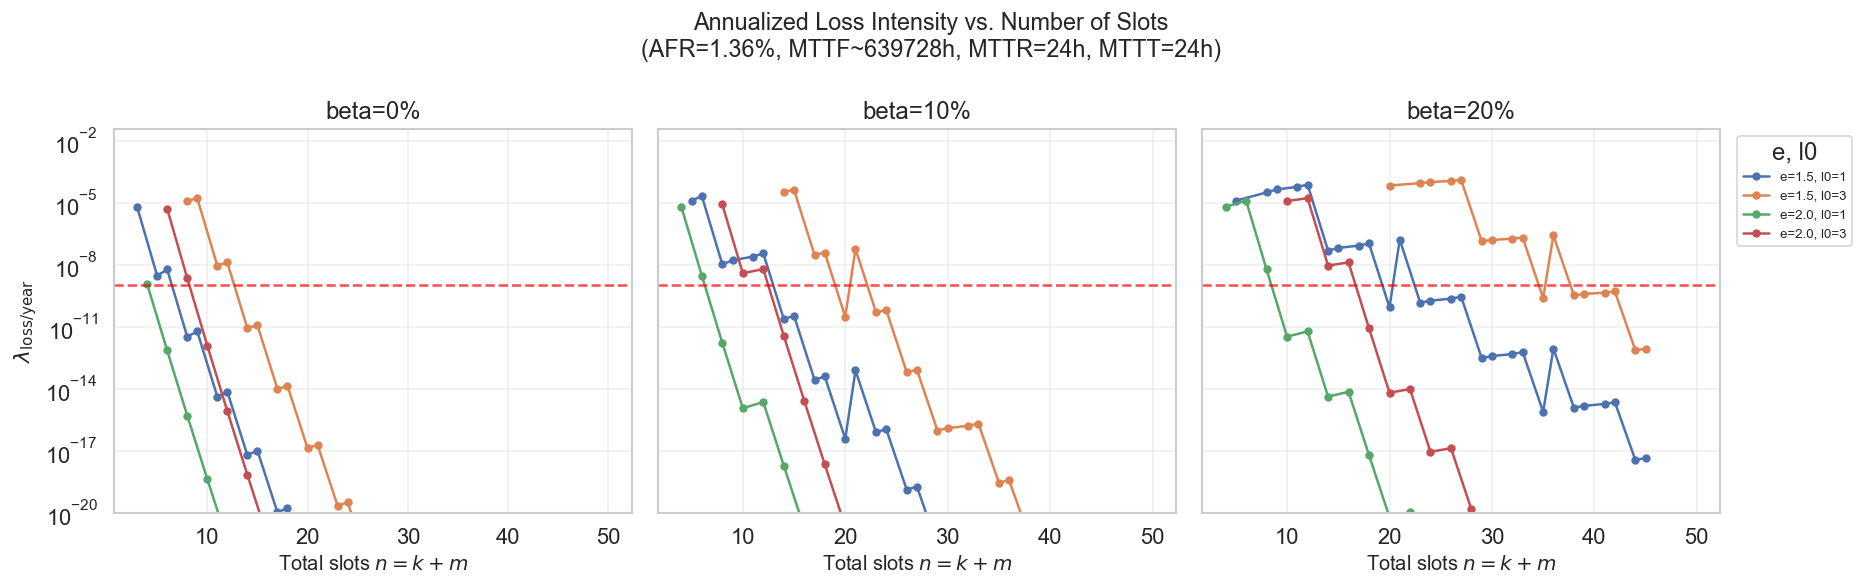

In [42]:
# Study 1: annualized loss intensity vs n for different expansion factors and repair thresholds
# Uses BASE_AFR, BASELINE_MTTT, BASELINE_MTTR, EXPANSION_FACTORS, R0_VALUES,
# K_MIN, K_MAX, N_CEIL, BETA_VALUES, and TARGET_LAMBDA_LOSS_YEAR from the model cell.
AFR = BASE_AFR
MTTF = mttf_hours_from_afr(AFR)
MTTR = BASELINE_MTTR
MTTT = BASELINE_MTTT
TARGET = TARGET_LAMBDA_LOSS_YEAR

results = []
for beta in BETA_VALUES:
    for e in EXPANSION_FACTORS:
        for l0 in R0_VALUES:
            for K in range(K_MIN, K_MAX + 1):
                N = math.ceil(K * e)
                M = N - K
                if M < l0 or N > N_CEIL:
                    continue
                budget = effective_code_with_byzantine_budget(K, N, beta)
                if not budget["feasible"] or budget["remaining_parity"] < l0:
                    continue
                lambda_hour = model_fail_per_hour(K, N, l0, MTTT, MTTF, MTTR, beta=beta)
                results.append(
                    {
                        "k": K,
                        "n": N,
                        "m": M,
                        "e": e,
                        "beta": beta,
                        "beta_pct": pct_str(beta),
                        "l0": l0,
                        "lambda_loss_year": lambda_hour * 8760,
                        "label": f"e={e}, l0={l0}",
                    }
                )

df1 = pd.DataFrame(results).sort_values(["beta", "e", "l0", "k"]).reset_index(drop=True)
df1["lambda_loss_year_sci"] = df1["lambda_loss_year"].map(sci_str)
df1["P_loss_1y_pct"] = df1["lambda_loss_year"].map(lambda_year_pct_str)

redundancy_summary_rows = []
for (beta, beta_pct, e, l0), group in df1.groupby(
    ["beta", "beta_pct", "e", "l0"], sort=False
):
    safe = group[group["lambda_loss_year"] < TARGET].sort_values("n")
    redundancy_summary_rows.append(
        {
            "beta": beta,
            "beta_pct": beta_pct,
            "e": e,
            "l0": l0,
            "min_n_meeting_target": safe["n"].iloc[0] if len(safe) else np.nan,
            "min_k_meeting_target": safe["k"].iloc[0] if len(safe) else np.nan,
            "lambda_at_smallest_n": group.sort_values("n")["lambda_loss_year"].iloc[0],
        }
    )

redundancy_summary_df = pd.DataFrame(redundancy_summary_rows)
redundancy_summary_df["min_n"] = redundancy_summary_df["min_n_meeting_target"].map(
    lambda x: str(int(x)) if pd.notna(x) else "not met in scanned range"
)

redundancy_summary_df["lambda_at_smallest_n_sci"] = redundancy_summary_df[
    "lambda_at_smallest_n"
].map(sci_str)

redundancy_summary_df["min_m"] = redundancy_summary_df.apply(
    lambda r: (
        str(int(r["min_n_meeting_target"] - r["min_k_meeting_target"]))
        if pd.notna(r["min_n_meeting_target"])
        else "-"
    ),
    axis=1,
)

display(
    redundancy_summary_df.sort_values(["beta", "e", "l0"])[
        [
            "beta_pct",
            "e",
            "l0",
            "min_k_meeting_target",
            "min_n",
            "min_m",
            "lambda_at_smallest_n_sci",
        ]
    ]
)

# ========================================================
# Plot: annualized loss intensity vs n
#

fig, axes = beta_subplots(BETA_VALUES, height=5, width_per_beta=5.25, sharey=True)

for ax, beta in zip(axes, BETA_VALUES):
    panel = df1[df1["beta"] == beta]
    for label, group in panel.groupby("label"):
        ax.semilogy(
            group["n"], group["lambda_loss_year"], "o-", label=label, markersize=4
        )
    add_loss_target_line(ax, TARGET)
    ax.set_title(f"beta={pct_str(beta)}")
    ax.set_xlabel("Total slots $n = k + m$", fontsize=12)
    ax.grid(True, which="both", alpha=0.3)
    ax.set_ylim(bottom=1e-20)

axes[0].set_ylabel("$\\lambda_{\\mathrm{loss/year}}$", fontsize=13)
axes[-1].legend(fontsize=8, title="e, l0", bbox_to_anchor=(1.02, 1), loc="upper left")
fig.suptitle(
    f"Annualized Loss Intensity vs. Number of Slots\n(AFR={pct_str(AFR)}, MTTF~{MTTF:.0f}h, MTTR={hours_label(MTTR)}, MTTT={hours_label(MTTT)})",
    fontsize=14,
)
plt.tight_layout()
plt.show()


### 4.2 Effect of Proof Frequency (MTTT)

**Question:** How often must storage proofs be checked to maintain durability?

We fix the shared baseline AFR, convert it to MTTF, hold MTTR at the shared
baseline `BASELINE_MTTR`, and sweep the proof intervals in `MTTT_SWEEP`
for the generated sensitivity configurations.

The current defaults span a compact operating band: a moderate object size,
lean-versus-full redundancy, and eager-versus-batched repair. The study
reports how much proof-cadence slack remains after reserving part of the
parity budget against Byzantine participation.


,config,k,m,m_eff,l0,beta_pct,max_MTTT_meeting_target,lambda@MTTT=24h,lambda@MTTT=72h,lambda@MTTT=168h
0,"k=3, n=5, m=2, l0=1",3,2,2,1,0%,not met in scanned range,2.889e-09,9.815e-09,3.747e-08
1,"k=3, n=6, m=3, l0=1",3,3,3,1,0%,168 h (7 d),6.934e-13,3.377e-12,2.325e-11
2,"k=3, n=6, m=3, l0=3",3,3,3,3,0%,not met in scanned range,4.997e-06,9.992e-06,1.998e-05
3,"k=5, n=8, m=3, l0=1",5,3,3,1,0%,168 h (7 d),3.235e-12,1.575e-11,1.083e-10
4,"k=5, n=8, m=3, l0=3",5,3,3,3,0%,not met in scanned range,1.182e-05,2.363e-05,4.723e-05
5,"k=5, n=10, m=5, l0=1",5,5,5,1,0%,168 h (7 d),4.171e-19,2.820e-18,5.035e-17
6,"k=5, n=10, m=5, l0=3",5,5,5,3,0%,168 h (7 d),1.204e-12,5.866e-12,4.043e-11
7,"k=10, n=15, m=5, l0=1",10,5,5,1,0%,168 h (7 d),9.927e-18,6.707e-17,1.195e-15
8,"k=10, n=15, m=5, l0=3",10,5,5,3,0%,168 h (7 d),1.182e-11,5.758e-11,3.965e-10
9,"k=10, n=20, m=10, l0=1",10,10,10,1,0%,168 h (7 d),1.368e-33,1.007e-32,4.917e-31


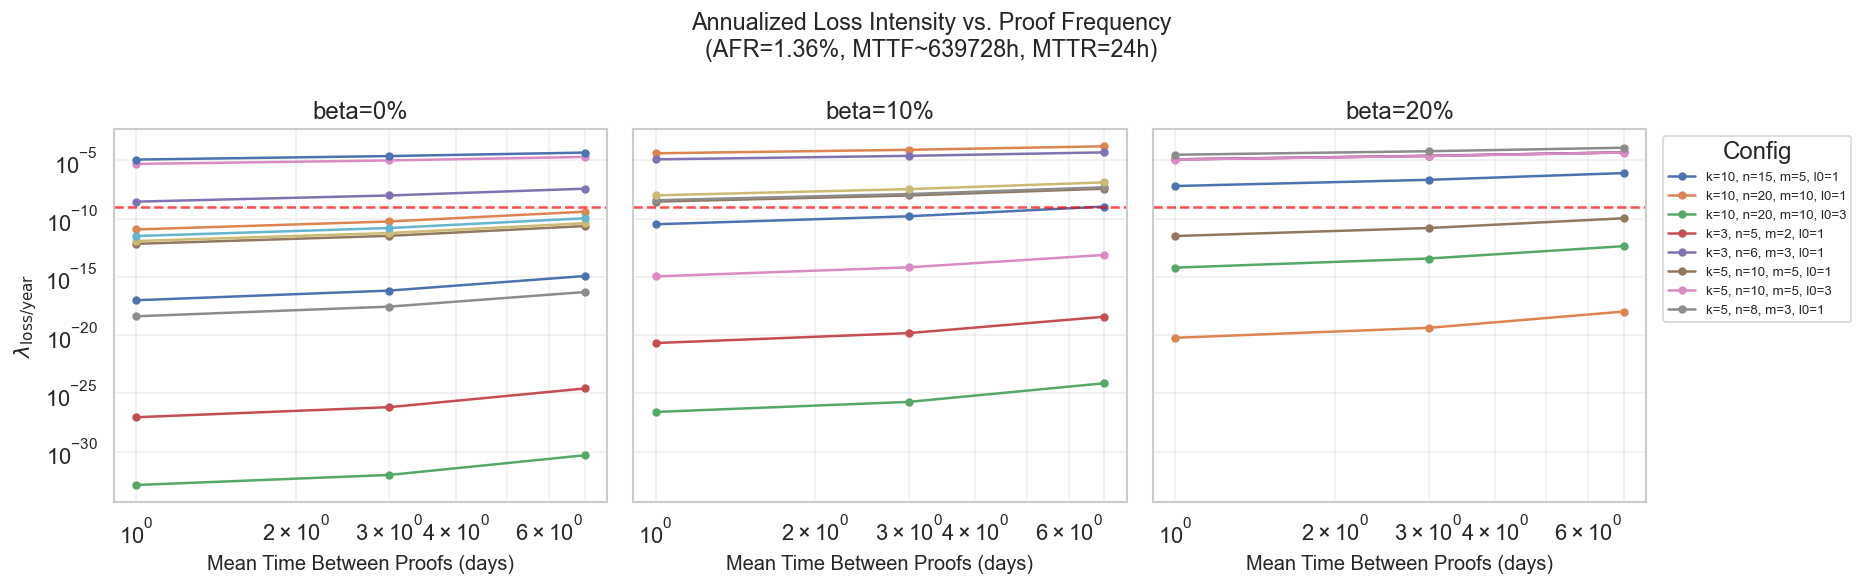

In [43]:
# Study 2: annualized loss intensity vs MTTT (proof frequency)
# Uses BASE_AFR, BASELINE_MTTR, MTTT_SWEEP, BETA_VALUES, SENSITIVITY_CONFIGS,
# and TARGET_LAMBDA_LOSS_YEAR from the model cell.
AFR = BASE_AFR
MTTF = mttf_hours_from_afr(AFR)
MTTR = BASELINE_MTTR
TARGET = TARGET_LAMBDA_LOSS_YEAR
mttt_values = list(MTTT_SWEEP)

results2 = []
for cfg in SENSITIVITY_CONFIGS:
    K = cfg["k"]
    N = cfg["n"]
    l0 = cfg["l0"]
    M = N - K
    config = code_config_label(K, N, l0=l0)
    for beta in BETA_VALUES:
        budget = effective_code_with_byzantine_budget(K, N, beta)
        if not budget["feasible"] or budget["remaining_parity"] < l0:
            continue

        m_eff = budget["remaining_parity"]
        for mttt in mttt_values:
            lambda_hour = model_fail_per_hour(K, N, l0, mttt, MTTF, MTTR, beta=beta)
            results2.append(
                {
                    "k": K,
                    "n": N,
                    "m": M,
                    "m_eff": m_eff,
                    "e": cfg["e"],
                    "l0": l0,
                    "beta": beta,
                    "beta_pct": pct_str(beta),
                    "config": config,
                    "label": f"{config}, beta={pct_str(beta)}",
                    "MTTT_hours": mttt,
                    "MTTT_days": mttt / 24,
                    "lambda_loss_year": lambda_hour * 8760,
                }
            )

df2 = pd.DataFrame(results2)
if len(df2):
    df2 = df2.sort_values(["beta", "k", "n", "l0", "MTTT_hours"]).reset_index(drop=True)
    df2["lambda_loss_year_sci"] = df2["lambda_loss_year"].map(sci_str)
    df2["P_loss_1y_pct"] = df2["lambda_loss_year"].map(lambda_year_pct_str)

    summary_index = ["beta", "beta_pct", "config", "k", "n", "m", "m_eff", "l0"]
    summary_rows = []
    for summary_key, group in df2.groupby(summary_index, sort=False):
        beta, beta_pct, config, k, n, m, m_eff, l0 = summary_key
        safe = group[group["lambda_loss_year"] < TARGET].sort_values("MTTT_hours")
        max_safe_hours = safe["MTTT_hours"].max() if len(safe) else np.nan
        summary_rows.append(
            {
                "beta": beta,
                "beta_pct": beta_pct,
                "config": config,
                "k": k,
                "n": n,
                "m": m,
                "m_eff": m_eff,
                "l0": l0,
                "max_MTTT_meeting_target_hours": max_safe_hours,
            }
        )

    proof_budget_df = pd.DataFrame(summary_rows)
    probe_table = (
        df2.pivot_table(
            index=summary_index,
            columns="MTTT_hours",
            values="lambda_loss_year",
            aggfunc="first",
        )
        .reindex(columns=mttt_values)
        .reset_index()
        .rename(
            columns={hours: lambda_probe_column("MTTT", hours) for hours in mttt_values}
        )
    )

    proof_budget_df = proof_budget_df.merge(probe_table, on=summary_index, how="left")
    proof_budget_df["max_MTTT_meeting_target"] = proof_budget_df[
        "max_MTTT_meeting_target_hours"
    ].map(lambda x: hours_day_display(x) if pd.notna(x) else "not met in scanned range")

    probe_display_names = {}
    for hours in mttt_values:
        raw_col = lambda_probe_column("MTTT", hours)
        sci_col = f"{raw_col}_sci"
        proof_budget_df[sci_col] = proof_budget_df[raw_col].map(sci_str)
        probe_display_names[sci_col] = probe_display_column("MTTT", hours)

    proof_display_cols = [
        "config",
        "k",
        "m",
        "m_eff",
        "l0",
        "beta_pct",
        "max_MTTT_meeting_target",
    ] + list(probe_display_names)

    display(
        proof_budget_df.sort_values(["beta", "k", "n", "l0"])[
            proof_display_cols
        ].rename(columns=probe_display_names)
    )
else:
    print("No feasible sensitivity configurations for the current Study 2 settings.")

# Plot: annualized loss intensity vs MTTT
if len(df2):
    fig, axes = beta_subplots(BETA_VALUES, height=5, width_per_beta=5.25, sharey=True)

    for ax, beta in zip(axes, BETA_VALUES):
        panel = df2[df2["beta"] == beta].copy()
        for config, group in panel.groupby("config"):
            ax.loglog(
                group["MTTT_days"],
                group["lambda_loss_year"],
                "o-",
                label=config,
                markersize=4,
            )
        add_loss_target_line(ax, TARGET)
        ax.set_title(f"beta={pct_str(beta)}")
        ax.set_xlabel("Mean Time Between Proofs (days)", fontsize=12)
        ax.grid(True, which="both", alpha=0.3)

    axes[0].set_ylabel("$\\lambda_{\\mathrm{loss/year}}$", fontsize=13)
    axes[-1].legend(
        fontsize=8, bbox_to_anchor=(1.02, 1), loc="upper left", title="Config"
    )

    fig.suptitle(
        f"Annualized Loss Intensity vs. Proof Frequency\n(AFR={pct_str(AFR)}, MTTF~{MTTF:.0f}h, MTTR={hours_label(MTTR)})",
        fontsize=14,
    )

    plt.tight_layout()
    plt.show()
else:
    print("No feasible sensitivity configurations for the current Study 2 settings.")


### 4.3 Effect of Repair Time (MTTR)

**Question:** How sensitive is durability to repair speed?

Using the same generated sensitivity configurations as Study 2, we hold
`MTTT = STUDY3_FIXED_MTTT_HOURS` and sweep the repair times in `MTTR_SWEEP`
at each $\beta$ level in `BETA_VALUES`.

This isolates MTTR as the moving dimension rather than mixing in
configuration-specific proof cadences.


,config,k,m,m_eff,l0,beta_pct,max_MTTR_meeting_target,lambda@MTTR=24h,lambda@MTTR=48h,lambda@MTTR=72h
0,"k=3, n=5, m=2, l0=1",3,2,2,1,0%,not met in scanned range,2.889e-09,7.508e-09,1.443e-08
1,"k=3, n=6, m=3, l0=1",3,3,3,1,0%,72h,6.934e-13,3.422e-12,9.782e-12
2,"k=3, n=6, m=3, l0=3",3,3,3,3,0%,not met in scanned range,4.997e-06,7.494e-06,9.991e-06
3,"k=5, n=8, m=3, l0=1",5,3,3,1,0%,72h,3.235e-12,1.596e-11,4.560e-11
4,"k=5, n=8, m=3, l0=3",5,3,3,3,0%,not met in scanned range,1.182e-05,1.772e-05,2.362e-05
5,"k=5, n=10, m=5, l0=1",5,5,5,1,0%,72h,4.171e-19,8.087e-18,5.190e-17
6,"k=5, n=10, m=5, l0=3",5,5,5,3,0%,72h,1.204e-12,5.938e-12,1.697e-11
7,"k=10, n=15, m=5, l0=1",10,5,5,1,0%,72h,9.927e-18,1.923e-16,1.232e-15
8,"k=10, n=15, m=5, l0=3",10,5,5,3,0%,72h,1.182e-11,5.827e-11,1.665e-10
9,"k=10, n=20, m=10, l0=1",10,10,10,1,0%,72h,1.368e-33,8.447e-31,4.098e-29


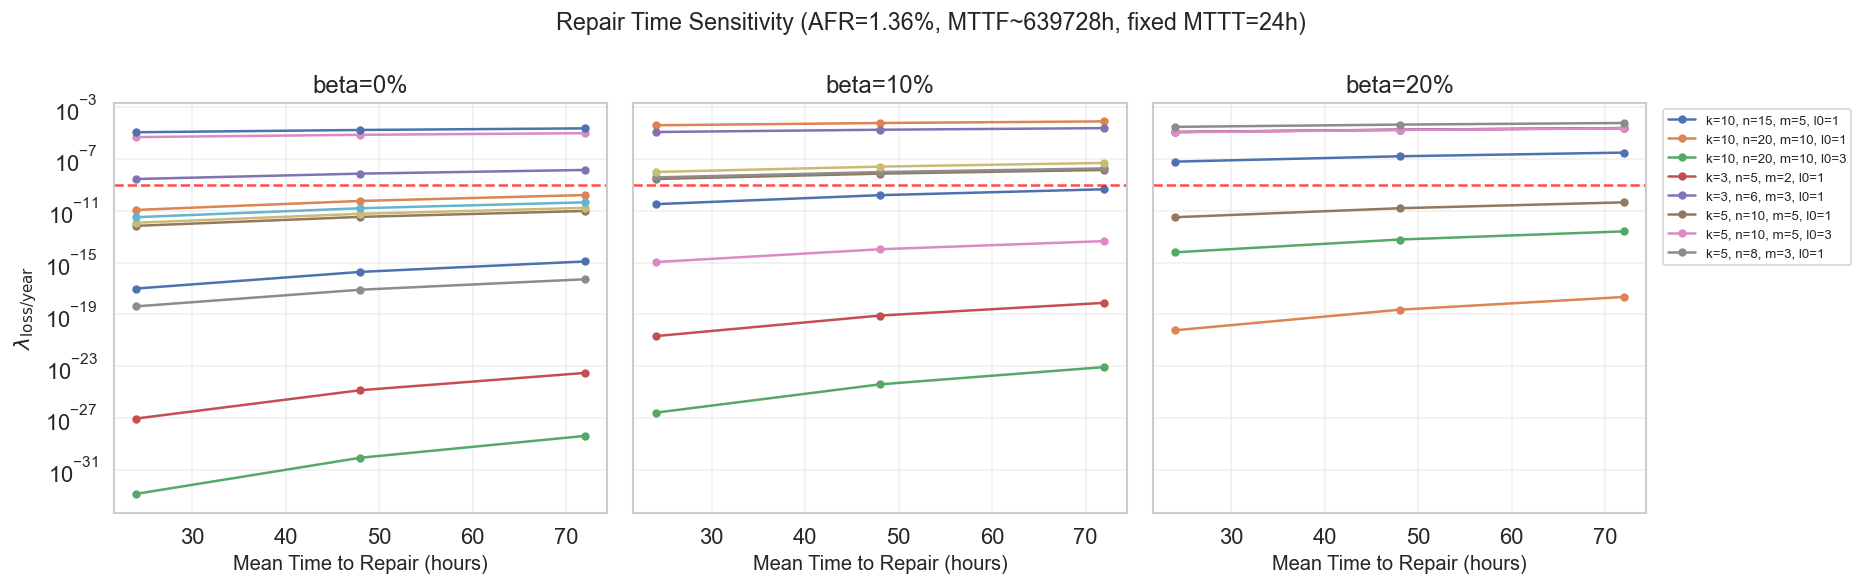

In [44]:
# Study 3: annualized loss intensity vs MTTR
# Uses BASE_AFR, MTTR_SWEEP, BETA_VALUES, SENSITIVITY_CONFIGS,
# STUDY3_FIXED_MTTT_HOURS, and TARGET_LAMBDA_LOSS_YEAR from the model cell.
AFR = BASE_AFR
MTTF = mttf_hours_from_afr(AFR)
TARGET = TARGET_LAMBDA_LOSS_YEAR
mttr_values = list(MTTR_SWEEP)
mttt = STUDY3_FIXED_MTTT_HOURS

results3 = []
for beta in BETA_VALUES:
    for cfg in SENSITIVITY_CONFIGS:
        K = cfg["k"]
        N = cfg["n"]
        l0 = cfg["l0"]
        M = N - K
        budget = effective_code_with_byzantine_budget(K, N, beta)
        if not budget["feasible"] or budget["remaining_parity"] < l0:
            continue

        m_eff = budget["remaining_parity"]
        config = code_config_label(K, N, l0=l0)
        for mttr in mttr_values:
            lambda_hour = model_fail_per_hour(K, N, l0, mttt, MTTF, mttr, beta=beta)
            results3.append(
                {
                    "k": K,
                    "n": N,
                    "m": M,
                    "m_eff": m_eff,
                    "l0": l0,
                    "MTTR": mttr,
                    "beta": beta,
                    "beta_pct": pct_str(beta),
                    "config": config,
                    "label": f"{config}, beta={pct_str(beta)}",
                    "lambda_loss_year": lambda_hour * 8760,
                }
            )


df3 = pd.DataFrame(results3)
if len(df3):
    df3 = df3.sort_values(["beta", "k", "n", "l0", "MTTR"]).reset_index(drop=True)
    df3["lambda_loss_year_sci"] = df3["lambda_loss_year"].map(sci_str)
    df3["P_loss_1y_pct"] = df3["lambda_loss_year"].map(lambda_year_pct_str)

    summary_index = ["beta", "beta_pct", "config", "k", "n", "m", "m_eff", "l0"]
    repair_summary_rows = []
    for summary_key, group in df3.groupby(summary_index, sort=False):
        beta, beta_pct, config, k, n, m, m_eff, l0 = summary_key
        safe = group[group["lambda_loss_year"] < TARGET].sort_values("MTTR")
        max_safe_mttr = safe["MTTR"].max() if len(safe) else np.nan
        repair_summary_rows.append(
            {
                "beta": beta,
                "beta_pct": beta_pct,
                "config": config,
                "k": k,
                "n": n,
                "m": m,
                "m_eff": m_eff,
                "l0": l0,
                "max_MTTR_meeting_target_hours": max_safe_mttr,
            }
        )

    repair_budget_df = pd.DataFrame(repair_summary_rows)
    probe_table = (
        df3.pivot_table(
            index=summary_index,
            columns="MTTR",
            values="lambda_loss_year",
            aggfunc="first",
        )
        .reindex(columns=mttr_values)
        .reset_index()
        .rename(
            columns={hours: lambda_probe_column("MTTR", hours) for hours in mttr_values}
        )
    )

    repair_budget_df = repair_budget_df.merge(probe_table, on=summary_index, how="left")
    repair_budget_df["max_MTTR_meeting_target"] = repair_budget_df[
        "max_MTTR_meeting_target_hours"
    ].map(lambda x: hours_label(x) if pd.notna(x) else "not met in scanned range")

    probe_display_names = {}
    for hours in mttr_values:
        raw_col = lambda_probe_column("MTTR", hours)
        sci_col = f"{raw_col}_sci"
        repair_budget_df[sci_col] = repair_budget_df[raw_col].map(sci_str)
        probe_display_names[sci_col] = probe_display_column("MTTR", hours)

    repair_display_cols = [
        "config",
        "k",
        "m",
        "m_eff",
        "l0",
        "beta_pct",
        "max_MTTR_meeting_target",
    ] + list(probe_display_names)

    display(
        repair_budget_df.sort_values(["beta", "k", "n", "l0"])[
            repair_display_cols
        ].rename(columns=probe_display_names)
    )

    fig, axes = beta_subplots(BETA_VALUES, height=5, width_per_beta=5.25, sharey=True)
    for ax, beta in zip(axes, BETA_VALUES):
        panel = df3[df3["beta"] == beta]
        for config, group in panel.groupby("config"):
            ax.semilogy(
                group["MTTR"],
                group["lambda_loss_year"],
                "o-",
                label=config,
                markersize=4,
            )
        add_loss_target_line(ax, TARGET)
        ax.set_title(f"beta={pct_str(beta)}")
        ax.set_xlabel("Mean Time to Repair (hours)", fontsize=12)
        ax.grid(True, which="both", alpha=0.3)

    axes[0].set_ylabel("$\\lambda_{\\mathrm{loss/year}}$", fontsize=13)
    axes[-1].legend(fontsize=8, bbox_to_anchor=(1.02, 1), loc="upper left")
    fig.suptitle(
        f"Repair Time Sensitivity (AFR={pct_str(AFR)}, MTTF~{MTTF:.0f}h, fixed MTTT={hours_label(mttt)})",
        fontsize=14,
    )
    plt.tight_layout()
    plt.show()
else:
    print("No feasible sensitivity configurations for the current Study 3 settings.")


### 4.4 Minimum Redundancy for the Shared Durability Target

**Question:** For a given expansion factor and reserved Byzantine fraction,
what is the minimum number of data slots $k$ (and hence total slots $n = \lceil k \cdot e \rceil$)
needed to meet the shared durability target?

We sweep integer $k$ values across the configured scan band from `K_MIN`
through `K_MAX`, subject to `N_CEIL`, and find the smallest feasible $k$
that stays below the shared annualized loss-intensity target for each
combination of expansion factor, repair threshold, proof interval, and
Byzantine reserve fraction.


In [45]:
# Study 4: minimum k (and corresponding n) to meet the nine-nines durability target
# Uses all shared scan settings from the model cell.
AFR = BASE_AFR
MTTF = mttf_hours_from_afr(AFR)
TARGET = TARGET_LAMBDA_LOSS_YEAR
results4 = []

for beta in BETA_VALUES:
    for e in EXPANSION_FACTORS:
        for l0 in R0_VALUES:
            for mttt in MTTT_STUDY_POINTS:
                for K in range(K_MIN, K_MAX + 1):
                    N = math.ceil(K * e)
                    M = N - K
                    if M < l0 or N > N_CEIL:
                        continue

                    budget = effective_code_with_byzantine_budget(K, N, beta)
                    if not budget["feasible"] or budget["remaining_parity"] < l0:
                        continue

                    lam = (
                        model_fail_per_hour(
                            K, N, l0, mttt, MTTF, BASELINE_MTTR, beta=beta
                        )
                        * 8760
                    )

                    if lam < TARGET:
                        results4.append(
                            {
                                "beta": beta,
                                "beta_pct": pct_str(beta),
                                "e": e,
                                "l0": l0,
                                "MTTT_hours": mttt,
                                "MTTT": hours_label(mttt),
                                "threshold": sci_str(TARGET),
                                "threshold_pct_1y": lambda_year_pct_str(TARGET),
                                "min_k": K,
                                "min_n": N,
                                "min_m": M,
                                "m_eff": budget["remaining_parity"],
                                "lambda_loss_year": lam,
                                "lambda_loss_year_sci": sci_str(lam),
                                "P_loss_1y_pct": lambda_year_pct_str(lam),
                            }
                        )
                        break

df4 = pd.DataFrame(results4)
if len(df4):
    df4 = df4.sort_values(["beta", "e", "l0", "MTTT_hours"]).reset_index(drop=True)
    display(
        df4[
            [
                "beta_pct",
                "e",
                "l0",
                "MTTT",
                "threshold",
                "min_k",
                "min_n",
                "min_m",
                "m_eff",
                "lambda_loss_year_sci",
                "P_loss_1y_pct",
            ]
        ]
    )
else:
    print("No configurations achieved target in scanned range.")


,beta_pct,e,l0,MTTT,threshold,min_k,min_n,min_m,m_eff,lambda_loss_year_sci,P_loss_1y_pct
0,0%,1.5,1,24h,1.000e-09,5,8,3,3,3.235e-12,0.00000000032%
1,0%,1.5,1,72h,1.000e-09,5,8,3,3,1.575e-11,0.00000000157%
2,0%,1.5,1,168h,1.000e-09,5,8,3,3,1.083e-10,0.00000001083%
3,0%,1.5,3,24h,1.000e-09,9,14,5,5,8.227e-12,0.00000000082%
4,0%,1.5,3,72h,1.000e-09,9,14,5,5,4.009e-11,0.00000000401%
5,0%,1.5,3,168h,1.000e-09,9,14,5,5,2.761e-10,0.00000002761%
6,0%,2.0,1,24h,1.000e-09,3,6,3,3,6.934e-13,0.00000000007%
7,0%,2.0,1,72h,1.000e-09,3,6,3,3,3.377e-12,0.00000000034%
8,0%,2.0,1,168h,1.000e-09,3,6,3,3,2.325e-11,0.00000000232%
9,0%,2.0,3,24h,1.000e-09,5,10,5,5,1.204e-12,0.00000000012%


In [46]:
# Pivot: minimum k for the shared target, by (beta, expansion, l0) x MTTT
if len(df4):
    pivot = (
        df4.pivot_table(
            index=["beta_pct", "e", "l0"],
            columns="MTTT_hours",
            values="min_k",
            aggfunc="first",
        )
        .reindex(columns=MTTT_STUDY_POINTS)
        .rename(columns={hours: hours_label(hours) for hours in MTTT_STUDY_POINTS})
    )
    pivot = pivot.apply(
        lambda col: col.map(lambda x: f"{int(x)}" if pd.notna(x) else "n/a")
    )
    display(pivot)
else:
    print("No configurations achieved target in scanned range.")


MTTT_hours      24h 72h 168h
beta_pct e   l0             
0%       1.5 1    5   5    5
             3    9   9    9
         2.0 1    3   3    3
             3    5   5    5
10%      1.5 1    9   9    9
             3   13  13   13
         2.0 1    4   4    4
             3    7   7    7
20%      1.5 1   13  13   19
             3   23  29   29
         2.0 1    5   5    5
             3    9   9    9

### 4.5 Feeding Audit Plans into the Durability Model

The companion audit notebook produces two quantities for a given audit plan:

- an effective proof interval $\mathrm{MTTT}_{eff}$,
- a per-touch detectability term $q_{det}$.

In this notebook, those map directly to the backend APIs as
`mttt=MTTT_eff` and `q_det=q_det`. The resulting per-lost-slot detection
hazard is still $q_{det} / \mathrm{MTTT}_{eff}$.

In [47]:
# Audit bridge: maps practical audit plans to the CTMC's MTTT parameter.
# Uses STANDARD_CONFIGS from the config cell and evaluates at each BETA_VALUES level.
#
# When beta > 0, the reserved slots are excluded from the proof universe,
# so the effective number of slots to cover is n_eff (not n).
AFR = BASE_AFR
MTTF = mttf_hours_from_afr(AFR)
MTTR = BASELINE_MTTR

rows = []
for bridge_cfg in STANDARD_CONFIGS:
    bridge_k = bridge_cfg["k"]
    bridge_n = bridge_cfg["n"]
    bridge_l0 = bridge_cfg["l0"]

    for beta in BETA_VALUES:
        budget = effective_code_with_byzantine_budget(bridge_k, bridge_n, beta)
        if not budget["feasible"] or budget["remaining_parity"] < bridge_l0:
            continue

        n_eff = budget["n_eff"]
        audit_plans = [
            {"name": "touch all daily", "touches_per_day": n_eff},
            {"name": "touch half daily", "touches_per_day": max(1, math.ceil(n_eff / 2))},
            {"name": "touch quarter daily", "touches_per_day": max(1, math.ceil(n_eff / 4))},
        ]

        for plan in audit_plans:
            mttt_eff = n_eff / plan["touches_per_day"] * 24
            lam = (
                model_fail_per_hour(
                    bridge_k, bridge_n, bridge_l0, mttt_eff, MTTF, MTTR, beta=beta
                )
                * 8760
            )

            rows.append(
                {
                    "config": code_config_label(bridge_k, bridge_n, l0=bridge_l0),
                    "plan": plan["name"],
                    "beta_pct": pct_str(beta),
                    "n_eff": n_eff,
                    "m_eff": budget["remaining_parity"],
                    "touches/day": plan["touches_per_day"],
                    "MTTT_eff (h)": round(mttt_eff, 1),
                    "lambda_loss_year": sci_str(lam),
                }
            )

bridge_df = pd.DataFrame(rows)
display(bridge_df)


,config,plan,beta_pct,n_eff,m_eff,touches/day,MTTT_eff (h),lambda_loss_year
0,"k=10, n=20, m=10, l0=3",touch all daily,0%,20,10,20,24.0,9.010e-28
1,"k=10, n=20, m=10, l0=3",touch half daily,0%,20,10,10,48.0,2.448e-27
2,"k=10, n=20, m=10, l0=3",touch quarter daily,0%,20,10,5,96.0,1.770e-26
3,"k=10, n=20, m=10, l0=3",touch all daily,10%,18,8,18,24.0,2.107e-21
4,"k=10, n=20, m=10, l0=3",touch half daily,10%,18,8,9,48.0,5.702e-21
5,"k=10, n=20, m=10, l0=3",touch quarter daily,10%,18,8,5,86.4,2.628e-20
6,"k=10, n=20, m=10, l0=3",touch all daily,20%,16,6,16,24.0,6.271e-15
7,"k=10, n=20, m=10, l0=3",touch half daily,20%,16,6,8,48.0,1.621e-14
8,"k=10, n=20, m=10, l0=3",touch quarter daily,20%,16,6,4,96.0,7.944e-14


## 5. Cross-Validation

To check that the three backends (analytical CTMC, discrete-time MC, event-driven MC)
agree, we run each on a common set of synthetic configurations with short MTTF (100 h)
for tractable Monte Carlo convergence.

Each configuration is evaluated at every $\beta$ level in `BETA_VALUES`.
The table reports the ratio of each MC estimate to the analytical baseline;
values near 1.0 confirm backend agreement.


In [48]:
# Cross-validation: compare analytical, discrete-time MC, and event-driven MC.
# Uses synthetic MTTF = 100 h for fast convergence; evaluates at each BETA_VALUES level.
CV_MAX_TIME = 1e6
CV_MAX_ITERS = 10000

cv_configs = [
    {"k": 3, "n": 6, "l0": 1, "mttt": 24, "mttf": 100, "mttr": 24},
    {"k": 5, "n": 10, "l0": 1, "mttt": 24, "mttf": 100, "mttr": 24},
    {"k": 5, "n": 10, "l0": 2, "mttt": 24, "mttf": 100, "mttr": 24},
    {"k": 10, "n": 20, "l0": 1, "mttt": 24, "mttf": 100, "mttr": 24},
    {"k": 10, "n": 20, "l0": 1, "mttt": 168, "mttf": 100, "mttr": 48},
    {"k": 10, "n": 20, "l0": 3, "mttt": 24, "mttf": 100, "mttr": 24},
]

cv_results = []
for cfg in cv_configs:
    config = code_config_label(
        cfg["k"], cfg["n"], l0=cfg["l0"], mttt=cfg["mttt"], mttr=cfg["mttr"]
    )
    for beta in BETA_VALUES:
        budget = effective_code_with_byzantine_budget(cfg["k"], cfg["n"], beta)
        if not budget["feasible"] or budget["remaining_parity"] < cfg["l0"]:
            continue

        lam_analytical = model_fail_per_hour(
            cfg["k"],
            cfg["n"],
            cfg["l0"],
            cfg["mttt"],
            cfg["mttf"],
            cfg["mttr"],
            beta=beta,
        )

        try:
            lam_discrete = simulate_discrete(
                cfg["k"],
                cfg["n"],
                cfg["l0"],
                cfg["mttt"],
                cfg["mttf"],
                cfg["mttr"],
                beta=beta,
                max_time=CV_MAX_TIME,
                max_iters=CV_MAX_ITERS,
            )
        except Exception:
            lam_discrete = float("nan")

        try:
            lam_event = simulate_events(
                cfg["k"],
                cfg["n"],
                cfg["l0"],
                cfg["mttt"],
                cfg["mttf"],
                cfg["mttr"],
                beta=beta,
                max_time=CV_MAX_TIME,
                max_iters=CV_MAX_ITERS,
            )
        except Exception:
            lam_event = float("nan")

        cv_results.append(
            {
                "config": config,
                "beta_pct": pct_str(beta),
                "m_eff": budget["remaining_parity"],
                "analytical": lam_analytical,
                "discrete": lam_discrete,
                "event": lam_event,
            }
        )

cv_df = pd.DataFrame(cv_results)
cv_df["ratio_disc"] = cv_df["discrete"] / cv_df["analytical"]
cv_df["ratio_event"] = cv_df["event"] / cv_df["analytical"]
cv_df["analytical_sci"] = cv_df["analytical"].map(sci_str)
cv_df["discrete_sci"] = cv_df["discrete"].map(
    lambda x: sci_str(x) if not np.isnan(x) else "n/a"
)
cv_df["event_sci"] = cv_df["event"].map(
    lambda x: sci_str(x) if not np.isnan(x) else "n/a"
)
cv_df["ratio_disc_str"] = cv_df["ratio_disc"].map(
    lambda x: f"{x:.2f}" if not np.isnan(x) else "n/a"
)
cv_df["ratio_event_str"] = cv_df["ratio_event"].map(
    lambda x: f"{x:.2f}" if not np.isnan(x) else "n/a"
)

display(
    cv_df[
        [
            "config",
            "beta_pct",
            "m_eff",
            "analytical_sci",
            "discrete_sci",
            "event_sci",
            "ratio_disc_str",
            "ratio_event_str",
        ]
    ]
)


,config,beta_pct,m_eff,analytical_sci,discrete_sci,event_sci,ratio_disc_str,ratio_event_str
0,"k=3, n=6, m=3, l0=1, MTTT=24h, MTTR=24h",0%,3,4.232e-03,4.190e-03,4.219e-03,0.99,1.00
1,"k=3, n=6, m=3, l0=1, MTTT=24h, MTTR=24h",10%,2,7.446e-03,7.485e-03,7.583e-03,1.01,1.02
2,"k=3, n=6, m=3, l0=1, MTTT=24h, MTTR=24h",20%,1,1.387e-02,1.392e-02,1.418e-02,1.00,1.02
3,"k=5, n=10, m=5, l0=1, MTTT=24h, MTTR=24h",0%,5,3.766e-03,3.710e-03,3.754e-03,0.99,1.00
4,"k=5, n=10, m=5, l0=1, MTTT=24h, MTTR=24h",10%,4,5.591e-03,5.627e-03,5.667e-03,1.01,1.01
5,"k=5, n=10, m=5, l0=1, MTTT=24h, MTTR=24h",20%,3,8.636e-03,8.540e-03,8.709e-03,0.99,1.01
6,"k=5, n=10, m=5, l0=2, MTTT=24h, MTTR=24h",0%,5,5.043e-03,5.026e-03,5.040e-03,1.00,1.00
7,"k=5, n=10, m=5, l0=2, MTTT=24h, MTTR=24h",10%,4,7.513e-03,7.562e-03,7.543e-03,1.01,1.00
8,"k=5, n=10, m=5, l0=2, MTTT=24h, MTTR=24h",20%,3,1.137e-02,1.123e-02,1.139e-02,0.99,1.00
9,"k=10, n=20, m=10, l0=1, MTTT=24h, MTTR=24h",0%,10,3.187e-03,3.153e-03,3.172e-03,0.99,1.00


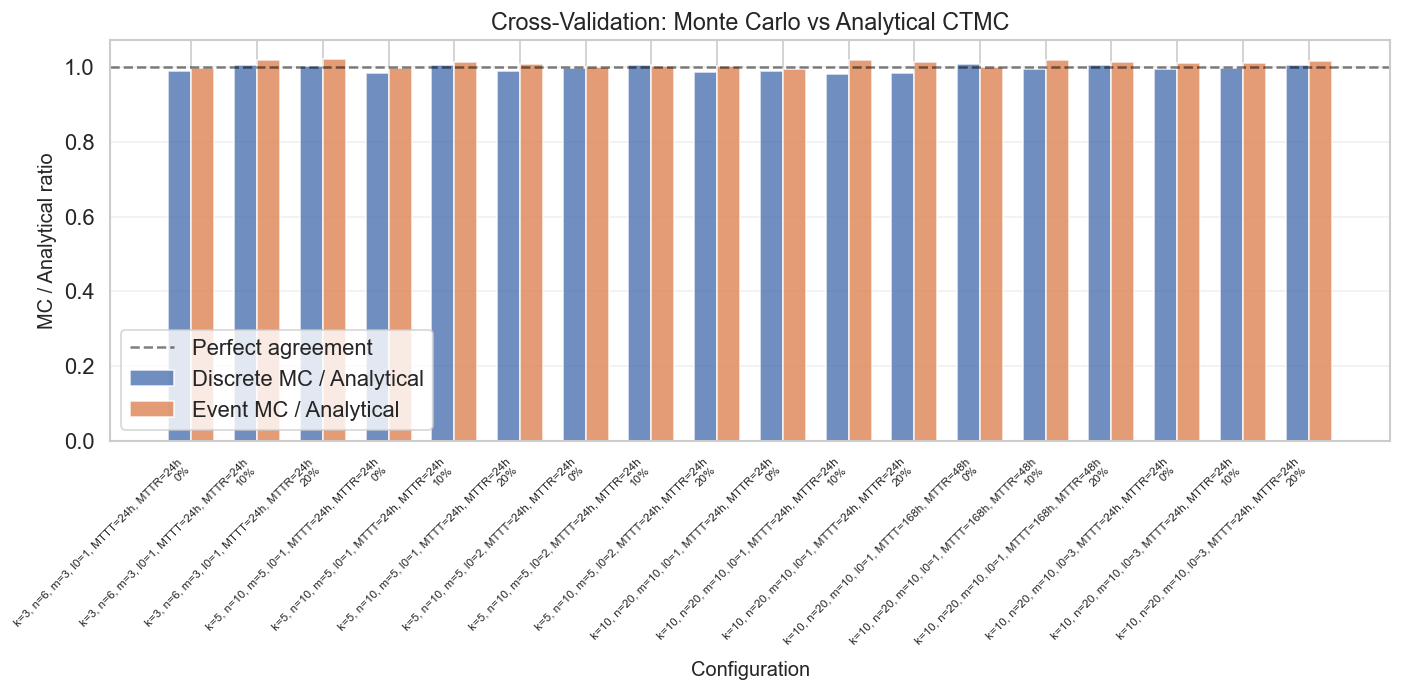

In [49]:
# Cross-validation: ratio of MC estimates to analytical baseline
fig, ax = plt.subplots(figsize=(12, 6))

x_labels = cv_df.apply(lambda r: f"{r['config']}\n{r['beta_pct']}", axis=1)
x = np.arange(len(cv_df))
width = 0.35

bars_disc = ax.bar(
  x - width / 2, cv_df["ratio_disc"], width, label="Discrete MC / Analytical", alpha=0.8
)
bars_event = ax.bar(
  x + width / 2, cv_df["ratio_event"], width, label="Event MC / Analytical", alpha=0.8
)

ax.axhline(y=1.0, color="black", linestyle="--", alpha=0.5, label="Perfect agreement")
ax.set_ylabel("MC / Analytical ratio", fontsize=12)
ax.set_xlabel("Configuration", fontsize=12)
ax.set_title("Cross-Validation: Monte Carlo vs Analytical CTMC", fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(x_labels, fontsize=7, rotation=45, ha="right")
ax.legend()
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()


## 6. Sensitivity Heatmaps

A global view of how $\lambda_{\text{loss/year}}$ depends on the two most
operationally important parameters: **proof frequency** (MTTT) and
**repair time** (MTTR).  The config(s) used are controlled by
`STANDARD_CONFIG_INDEX` in the configuration cell — set it to a grid
index for a single operating point, or `None` to generate heatmaps
for every config in `SENSITIVITY_CONFIGS`.


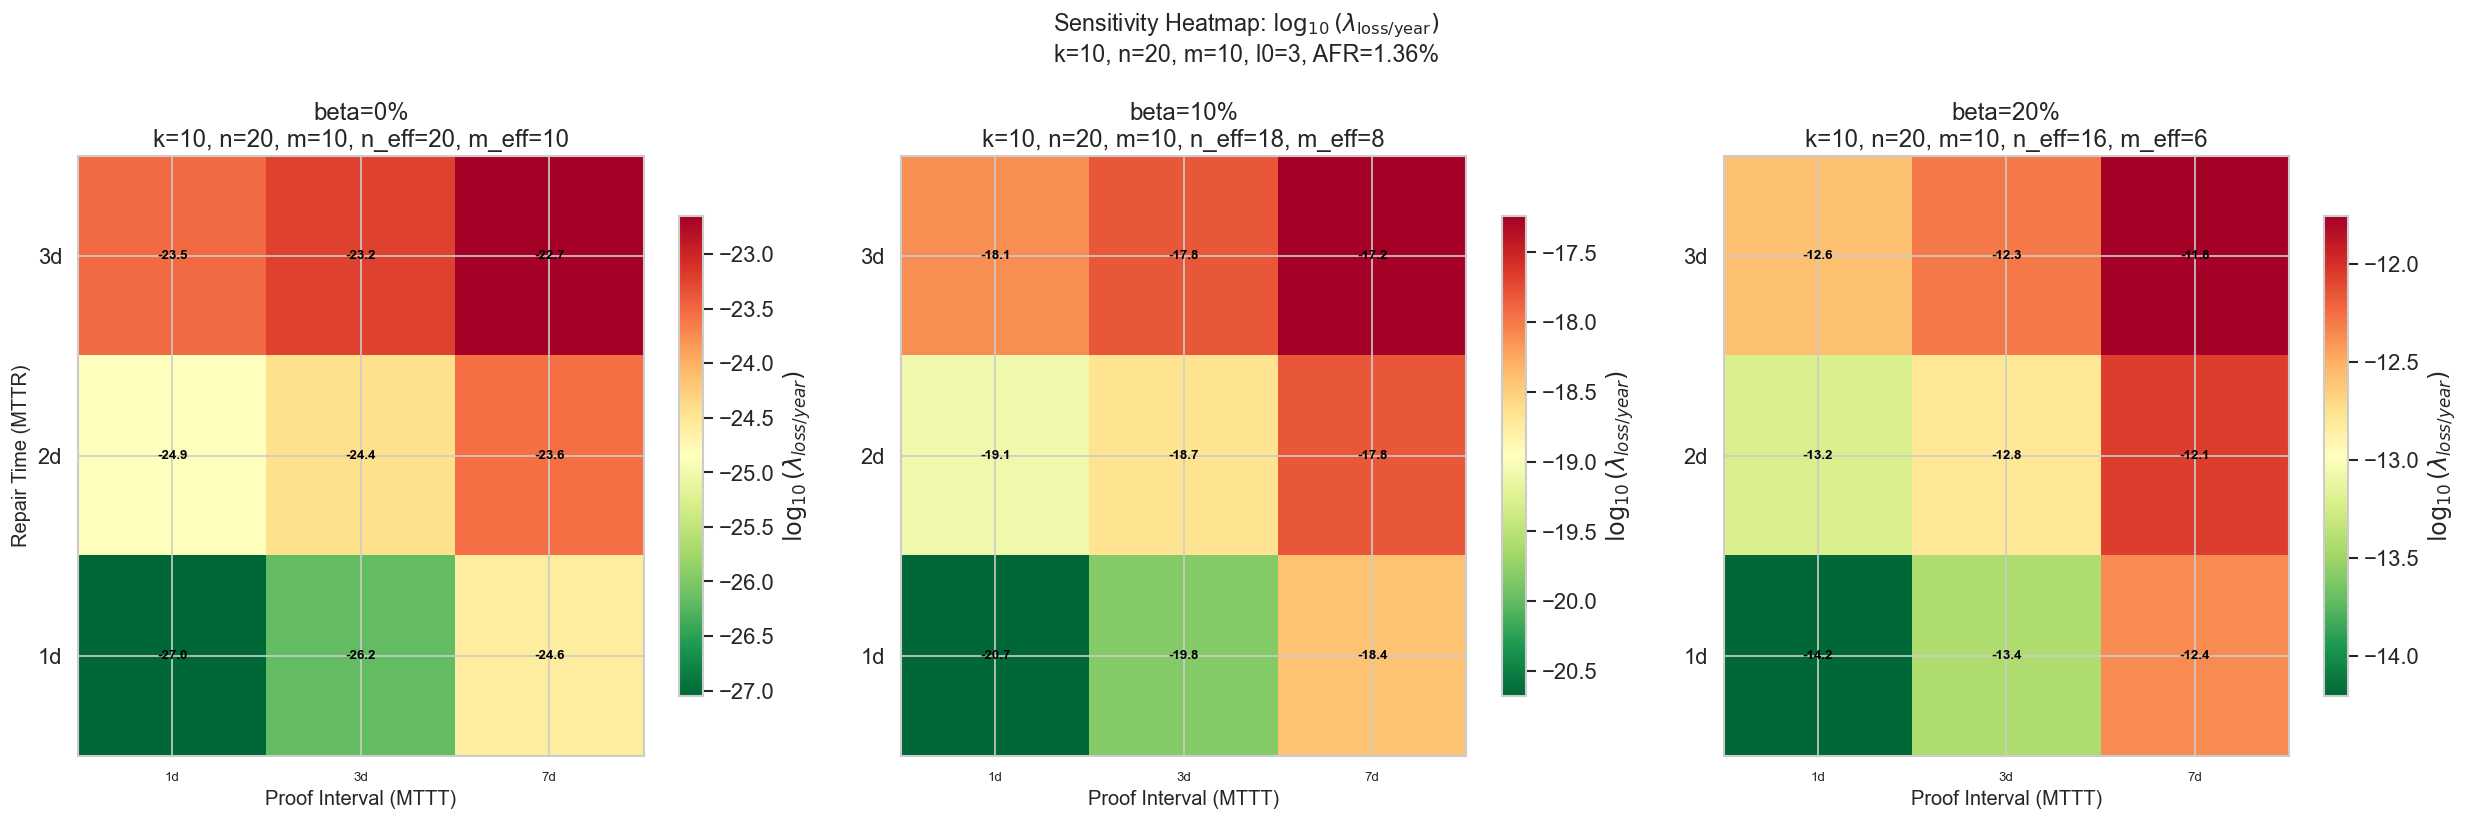

In [50]:
# Heatmap: annualized loss intensity as function of MTTT and MTTR.
# Produces one figure per config in STANDARD_CONFIGS, each with
# one panel per beta value.
AFR = BASE_AFR
MTTF = mttf_hours_from_afr(AFR)

mttt_range = list(MTTT_SWEEP)
mttr_range = list(MTTR_SWEEP)

for heatmap_cfg in STANDARD_CONFIGS:
    K = heatmap_cfg["k"]
    N = heatmap_cfg["n"]
    R0 = heatmap_cfg["l0"]

    fig, axes = beta_subplots(BETA_VALUES, height=7, width_per_beta=7.0, sharey=False)
    for ax, beta in zip(axes, BETA_VALUES):
        budget = effective_code_with_byzantine_budget(K, N, beta)
        if not budget["feasible"] or budget["remaining_parity"] < R0:
            ax.set_title(
                f"beta={pct_str(beta)} - INFEASIBLE\n"
                f"(reserve {budget['reserve_slots']}, m_eff={budget['remaining_parity']}, l0={R0})"
            )
            ax.axis("off")
            continue

        heat = np.zeros((len(mttr_range), len(mttt_range)))
        for i, mttr in enumerate(mttr_range):
            for j, mttt in enumerate(mttt_range):
                p = model_fail_per_hour(K, N, R0, mttt, MTTF, mttr, beta=beta)
                heat[i, j] = np.log10(max(p * 8760, 1e-30))

        im = ax.imshow(heat, aspect="auto", cmap="RdYlGn_r", origin="lower")
        ax.set_xticks(range(len(mttt_range)))
        ax.set_xticklabels([hours_tick_label(h) for h in mttt_range], fontsize=8)
        ax.set_yticks(range(len(mttr_range)))
        ax.set_yticklabels([hours_tick_label(h) for h in mttr_range])
        ax.set_xlabel("Proof Interval (MTTT)", fontsize=12)
        ax.set_title(
            f"beta={pct_str(beta)}\nk={K}, n={N}, m={N - K}, n_eff={budget['n_eff']}, m_eff={budget['remaining_parity']}"
        )

        for i in range(len(mttr_range)):
            for j in range(len(mttt_range)):
                color = "white" if heat[i, j] > -5 else "black"
                ax.text(
                    j,
                    i,
                    f"{heat[i, j]:.1f}",
                    ha="center",
                    va="center",
                    fontsize=8,
                    color=color,
                    fontweight="bold",
                )
        fig.colorbar(im, ax=ax, label=r"$\log_{10}(\lambda_{loss/year})$", shrink=0.8)

    axes[0].set_ylabel("Repair Time (MTTR)", fontsize=12)
    fig.suptitle(
        f"Sensitivity Heatmap: $\log_{{10}}(\lambda_{{\mathrm{{loss/year}}}})$\n"
        f"k={K}, n={N}, m={N - K}, l0={R0}, AFR={pct_str(AFR)}",
        fontsize=14,
    )
    plt.tight_layout()
    plt.show()


## 7. Reference Tables

### 7.1 Configurations Meeting the Shared Durability Target

The following table summarizes configurations that stay below the shared
annualized loss-intensity target under the baseline independent-failure
and effective-detection assumptions of this notebook, evaluated at each
Byzantine reserve level in `BETA_VALUES`.


In [51]:
# Reference table: configurations that achieve nine-nines durability
# Uses all shared scan settings from the model cell.
AFR = BASE_AFR
MTTF = mttf_hours_from_afr(AFR)
TARGET = TARGET_LAMBDA_LOSS_YEAR
ref_rows = []

for beta in BETA_VALUES:
    for e in EXPANSION_FACTORS:
        for l0 in R0_VALUES:
            for mttt in MTTT_STUDY_POINTS:
                for mttr in MTTR_STUDY_POINTS:
                    for K in range(K_MIN, K_MAX + 1):
                        N = math.ceil(K * e)
                        M = N - K
                        if M < l0 or N > N_CEIL:
                            continue
                        budget = effective_code_with_byzantine_budget(K, N, beta)
                        if not budget["feasible"] or budget["remaining_parity"] < l0:
                            continue
                        lam = (
                            model_fail_per_hour(K, N, l0, mttt, MTTF, mttr, beta=beta)
                            * 8760
                        )
                        if lam < TARGET:
                            ref_rows.append(
                                {
                                    "beta": beta,
                                    "Reserved Byzantine fraction": pct_str(beta),
                                    "Expansion (e)": e,
                                    "Repair threshold (l0)": l0,
                                    "MTTT (h)": mttt,
                                    "MTTR (h)": mttr,
                                    "Min k": K,
                                    "Min n": N,
                                    "Parity (m)": M,
                                    "m_eff": budget["remaining_parity"],
                                    "lambda_loss_year": lam,
                                    "lambda_loss_year_sci": sci_str(lam),
                                }
                            )
                            break

ref_df = pd.DataFrame(ref_rows)
if len(ref_df):
    display(
        ref_df.sort_values(
            ["beta", "Expansion (e)", "Repair threshold (l0)", "MTTT (h)", "MTTR (h)"]
        )[
            [
                "Reserved Byzantine fraction",
                "Expansion (e)",
                "Repair threshold (l0)",
                "MTTT (h)",
                "MTTR (h)",
                "Min k",
                "Min n",
                "Parity (m)",
                "m_eff",
                "lambda_loss_year_sci",
            ]
        ]
    )
else:
    print("No configurations achieved target in scanned range.")


,Reserved Byzantine fraction,Expansion (e),Repair threshold (l0),MTTT (h),MTTR (h),Min k,Min n,Parity (m),m_eff,lambda_loss_year_sci
0,0%,1.5,1,24,24,5,8,3,3,3.235e-12
1,0%,1.5,1,24,48,5,8,3,3,1.596e-11
2,0%,1.5,1,24,72,5,8,3,3,4.560e-11
3,0%,1.5,1,72,24,5,8,3,3,1.575e-11
4,0%,1.5,1,72,48,5,8,3,3,4.056e-11
...,...,...,...,...,...,...,...,...,...,...
103,20%,2.0,3,72,48,9,18,9,5,1.032e-10
104,20%,2.0,3,72,72,9,18,9,5,2.215e-10
105,20%,2.0,3,168,24,9,18,9,5,2.761e-10
106,20%,2.0,3,168,48,9,18,9,5,4.374e-10


## 8. Key Findings & Design Recommendations

### 8.1 Summary of Results

1. **The shared annualized loss-intensity target is achievable with realistic AFR inputs.**
   Within the scanned design band, moderate redundancy is sufficient under the
   independent-failure and effective-detection assumptions used here.

2. **Proof cadence slack depends strongly on code margin.**
   Within the current proof-interval scan (`MTTT_SWEEP`), weaker configurations
   consume proof headroom faster than stronger ones.

3. **Repair time remains a strong lever within the shared repair-time scan.**
   Within `MTTR_SWEEP`, loss intensity rises materially as repair slows,
   even when some configurations remain below target.

4. **Higher repair thresholds can be viable when redundancy margin is available.**
   The shared `R0_VALUES` scan shows that repair suppression can trade against
   extra coding headroom.

5. **Higher expansion factors buy operational slack.**
   Across `EXPANSION_FACTORS`, fuller-coded settings retain more proof-cadence
   and repair-time headroom than leaner ones.

6. **Byzantine reserve ($\beta$) reduces effective parity predictably.**
   Raising the reserved Byzantine fraction consumes parity budget and pushes the
   minimum viable code size upward. The parameter studies (Sections 4.1-4.4)
   and reference table (Section 7) include $\beta$ as a first-class dimension.

### 8.2 Design Recommendations

| Recommendation | Rationale |
|----------------|-----------|
| **Use expansion with explicit headroom** | Leaner codes can be viable, but fuller-coded settings retain more proof and repair margin under the same failure assumptions |
| **Keep repair time inside the validated operating band** | The scanned repair-time band is informative for the current study, but slower repair erodes durability quickly |
| **Size proof cadence to measured margin** | Proof slack varies materially by code margin; rerun the sweep before claiming support for slower cadences than those scanned |
| **Start with lower repair thresholds and relax only with evidence** | Higher `l0` can save repair work, but it should be justified against real redundancy headroom |
| **Treat Byzantine reserve as an explicit design input** | Always verify the selected $(k, n)$ after reserving $\lceil \beta n \rceil$ slots from the parity budget |
| **Calibrate failure inputs empirically** | Disk failure rates vary by hardware; recalibrate with observed AFR or MTTF data |

### 8.3 Model Limitations

- **Independent failures assumed:** Correlated failures (e.g., datacenter
  outages) would increase $P_{\text{loss}}$ and require geographic dispersal modeling.
- **Detection represented by an effective hazard:** The model compresses audit cadence,
  detectability, and proof verification into $q_{det} / \mathrm{MTTT}_{eff}$.
- **Full repair:** Repair restores all slots simultaneously; partial repair
  strategies could be modeled for optimization.
- **Byzantine reserve is deterministic, not stochastic:** The model reserves
  $b = \lceil \beta n \rceil$ parity slots as a fixed budget rather than modeling
  Byzantine faults as a stochastic process. This is conservative: if fewer than $b$
  nodes are actually adversarial, the effective margin is better than reported.

### 8.4 Natural Extensions

- Incorporate **correlated failure modes** (rack, datacenter, region)
- Model **stochastic Byzantine behavior** with time-varying adversarial fraction
  and correlate it with the deterministic reserve budget used here
- Add **economic cost modeling** (storage overhead x SP fees x proof gas costs)
- Extend to **dynamic networks** with SP churn
- Stress-test against **alternative AFR assumptions** and provider-specific field data

---

## Methodology Notes

This analysis uses three computational methods:

| Method | Type | Speed | Accuracy | Best For |
|--------|------|-------|----------|----------|
| **CTMC** | Analytical | Fast | Exact (numerical) | Production parameter sweeps |
| **Discrete-time MC** | Simulation | Slow | Approximate (configured finite timestep) | Quantitative cross-check |
| **Event-driven MC** | Simulation | Medium | Exact for the same CTMC assumptions | Primary simulation validation |

In the validation block, each simulator runs for a fixed time horizon
(`CV_MAX_TIME`) or iteration count (`CV_MAX_ITERS`), whichever binds first.
The ratio of each MC estimate to the analytical CTMC baseline is reported;
event-driven simulation should agree most closely, while any discrete-time
gap reflects configured timestep-discretization error rather than a
model-structure disagreement.

**Source code:** All analysis code is available in the
[archivist-research](https://github.com/durability-labs/archivist-research)
repository.

---

*Generated by the Archivist Reliability Analysis framework.*
*For questions or contributions, see the repository README.*
